# Notebook 12 — ML benchmarking for TCSPC lifetime estimation

This notebook integrates the Week 7 benchmarking framework and compares
physics-inspired, machine-learning, and classical reconvolution estimators
for fluorescence-lifetime estimation from synthetic TCSPC histograms.

The benchmark addresses four main questions:

1. How much lifetime information is captured by engineered features,
   normalized histogram bins, and PCA-compressed histograms?
2. Under which physical conditions do different estimators perform well
   or fail?
3. How robust are classical and ML estimators when the assumed
   mono-exponential forward model is deliberately violated?
4. What is the computational cost of inference for each estimator?

All estimators use a common reproducible train/test split.
Simulation metadata is used only for evaluation and stratification,
not as model input.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.benchmark_plots import (
    plot_error_histogram,
    plot_error_vs_condition,
    plot_paired_absolute_error_comparison,
    plot_true_vs_predicted,
)
from tcspc_toolkit.classical_evaluation import (
    evaluate_reconvolution_benchmark,
)
from tcspc_toolkit.conditional_evaluation import (
    add_benchmark_regimes,
    build_classical_prediction_diagnostics,
    build_prediction_diagnostics,
    build_ml_prediction_diagnostics,
    summarize_standard_regimes,
)
from tcspc_toolkit.config import FeatureConfig
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
)
from tcspc_toolkit.mismatch_evaluation import (
    evaluate_classical_mismatch_benchmark,
    evaluate_ml_mismatch_benchmark,
    generate_matched_biexponential_mismatch_dataset,
    summarize_mismatch_benchmark,
)
from tcspc_toolkit.ml_evaluation import (
    build_benchmark_dataset,
    build_histogram_representations,
    evaluate_baselines,
    evaluate_nonlinear_representation_benchmark,
    evaluate_photon_count_ablation,
    evaluate_regressor,
    evaluate_ridge_representation_benchmark,
    generate_benchmark_measurements,
    split_benchmark_dataset,
    summarize_split_coverage,
    summarize_split_level_balance,
)
from tcspc_toolkit.ml_models import (
    make_hist_gradient_boosting_pipeline,
    make_random_forest_pipeline,
    make_ridge_pipeline,
)
from tcspc_toolkit.timing_evaluation import (
    benchmark_inference_runtime,
    summarize_inference_timing,
)
from tcspc_toolkit.representations import (
    cumulative_explained_variance,
)

## 1. Benchmark dataset and fixed split

The earlier Week 7 development benchmark used a compact parameter grid
to develop and test the benchmarking infrastructure.

For the final scientific benchmark, a richer factorial design is used so
that all conditional-evaluation regimes are populated explicitly.

The benchmark varies:

- fluorescence lifetime,
- signal photon count,
- background level,
- IRF width,
- IRF temporal shift.

The parameter levels are chosen to span low/intermediate/high or
short/intermediate/long physical regimes while keeping the benchmark
small enough for classical reconvolution fitting.

All combinations are simulated. A single reproducible train/test split
is then reused throughout the notebook for every estimator and
representation.

### 1.1 Benchmark parameter grid

The final scientific benchmark uses a full factorial parameter grid
covering the main physical conditions expected to influence TCSPC
lifetime estimation.

The simulated variables are:

- fluorescence lifetime,
- signal photon count,
- background level,
- IRF width,
- IRF temporal shift.

The selected values deliberately span short-to-long lifetimes,
low-to-high photon counts and backgrounds, and increasingly challenging
IRF conditions.

Unlike the smaller development benchmark used earlier in Week 7, this
grid is designed to populate all conditional-performance regimes used
later in the notebook.

In [2]:
time = np.arange(
    0.0,
    20.0,
    0.05,
    dtype=np.float64,
)

lifetimes_ns = np.array(
    [
        0.5,
        1.0,
        2.0,
        3.0,
        4.5,
        6.0,
    ],
    dtype=np.float64,
)

signal_photon_counts = np.array(
    [
        1_000,
        10_000,
        100_000,
    ],
    dtype=np.int64,
)

background_levels = np.array(
    [
        0.0,
        0.5,
        2.0,
    ],
    dtype=np.float64,
)

irf_centre_ns = 1.0

irf_fwhm_values_ns = np.array(
    [
        0.15,
        0.30,
        0.60,
    ],
    dtype=np.float64,
)

irf_shift_values_ns = np.array(
    [
        -0.20,
        -0.05,
        0.00,
        0.05,
        0.20,
    ],
    dtype=np.float64,
)

### 1.2 Conditional-regime boundaries

For later performance analysis, the numerical benchmark conditions are
mapped onto physically interpretable regimes.

The boundaries below define:

- short, medium, and long lifetimes,
- low, medium, and high photon counts,
- low, medium, and high background,
- narrow, medium, and broad IRFs,
- small, medium, and large IRF misalignment.

These boundaries are defined before model evaluation so that the regime
classification is fixed independently of estimator performance.

IRF misalignment is evaluated using the absolute IRF shift, so positive
and negative shifts of equal magnitude belong to the same regime.

In [3]:
LIFETIME_EDGES = np.array(
    [
        0.0,
        1.5,
        3.5,
        np.inf,
    ],
    dtype=np.float64,
)

PHOTON_COUNT_EDGES = np.array(
    [
        0.0,
        5_000,
        50_000,
        np.inf,
    ],
    dtype=np.float64,
)

BACKGROUND_EDGES = np.array(
    [
        0.0,
        0.25,
        1.0,
        np.inf,
    ],
    dtype=np.float64,
)

IRF_WIDTH_EDGES = np.array(
    [
        0.0,
        0.225,
        0.45,
        np.inf,
    ],
    dtype=np.float64,
)

IRF_MISALIGNMENT_EDGES = np.array(
    [
        0.0,
        0.025,
        0.10,
        np.inf,
    ],
    dtype=np.float64,
)

### 1.3 Feature-extraction and reproducibility settings

The benchmark uses the engineered-feature definitions developed in
Week 6, with feature windows adjusted to remain valid across the broader
0.5–6 ns lifetime range used here.

Random seeds are fixed for both simulation and train/test splitting so
that the complete benchmark is reproducible.

A fixed 80/20 split is used throughout the notebook. The resulting
training and test samples are reused for all baseline, machine-learning,
representation, and classical-fitting comparisons.

In [4]:
feature_config = FeatureConfig(
    tail_start_ns=2.0,
    early_stop_ns=2.0,
    late_start_ns=3.0,
)

RANDOM_SEED = 42
SPLIT_RANDOM_STATE = 42

TEST_SIZE = 0.20

The resulting factorial benchmark contains

$$
6 \times 3 \times 3 \times 3 \times 5 = 810
$$

synthetic TCSPC histograms.

The 20% test split therefore contains 162 samples and the training set
contains 648 samples.

### 1.4 Benchmark generation and feature-validity check

The complete factorial parameter grid is now simulated as IRF-convolved,
Poisson-sampled TCSPC histograms.

Before constructing the engineered-feature table, the benchmark is
checked explicitly for two conditions required by the feature extractor:

1. each histogram must contain enough positive-count bins in the selected
   tail region for log-slope regression;
2. the late-count region must contain nonzero counts for the
   early-to-late count ratio.

These checks are particularly important for short, low-photon decays,
where very late histogram regions may contain no detected photons.

Only after verifying feature validity is the complete benchmark dataset
constructed and split into fixed training and test subsets.

In [5]:
benchmark_measurements = generate_benchmark_measurements(
    time=time,
    lifetimes_ns=lifetimes_ns,
    signal_photon_counts=signal_photon_counts,
    background_levels=background_levels,
    irf_centre_ns=irf_centre_ns,
    irf_fwhm_values_ns=irf_fwhm_values_ns,
    irf_shift_values_ns=irf_shift_values_ns,
    random_seed=RANDOM_SEED,
)

In [6]:
tail_mask = (
    time >= feature_config.tail_start_ns
)

late_mask = (
    time >= feature_config.late_start_ns
)

positive_tail_bins = np.sum(
    (
        benchmark_measurements.X_histograms[
            :,
            tail_mask,
        ]
        > 0
    ),
    axis=1,
)

late_counts = np.sum(
    benchmark_measurements.X_histograms[
        :,
        late_mask,
    ],
    axis=1,
)

print(
    "Minimum positive tail bins:",
    positive_tail_bins.min(),
)

print(
    "Curves below min_tail_points:",
    np.sum(
        positive_tail_bins
        < feature_config.min_tail_points
    ),
)

print(
    "Minimum late-region counts:",
    late_counts.min(),
)

print(
    "Curves with zero late counts:",
    np.sum(
        late_counts == 0
    ),
)

Minimum positive tail bins: 26
Curves below min_tail_points: 0
Minimum late-region counts: 10
Curves with zero late counts: 0


In [7]:
benchmark_dataset = build_benchmark_dataset(
    benchmark_measurements,
    feature_config=feature_config,
)

benchmark_split = split_benchmark_dataset(
    benchmark_dataset,
    test_size=TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)

The engineered-feature windows used in earlier development experiments were adjusted for the broader final benchmark domain. In particular, short low-photon decays can contain essentially no detected photons at very late times, making a fixed 5–7 ns tail definition mathematically undefined. The final configuration therefore uses earlier tail and late-count regions that remain applicable across the full 0.5–6 ns lifetime range.

### 1.5 Dataset dimensions

The complete factorial benchmark is now converted into raw histograms,
engineered features, lifetime targets, and evaluation metadata.

Before any estimator is trained, we verify that all representations remain
aligned and that the expected train/test split was produced.

In [8]:
print(
    "Histograms:",
    benchmark_dataset.X_histograms.shape,
)

print(
    "Engineered features:",
    benchmark_dataset.X_features.shape,
)

print(
    "Targets:",
    benchmark_dataset.y.shape,
)

print(
    "Metadata:",
    benchmark_dataset.metadata.shape,
)

print(
    "Training samples:",
    benchmark_split.y_train.size,
)

print(
    "Test samples:",
    benchmark_split.y_test.size,
)

Histograms: (810, 400)
Engineered features: (810, 15)
Targets: (810,)
Metadata: (810, 9)
Training samples: 648
Test samples: 162


In [9]:
n_expected_samples = 810

assert (
    benchmark_dataset.X_histograms.shape[0]
    == n_expected_samples
)

assert (
    benchmark_dataset.X_features.shape[0]
    == n_expected_samples
)

assert (
    benchmark_dataset.y.size
    == n_expected_samples
)

assert (
    benchmark_dataset.metadata.shape[0]
    == n_expected_samples
)

### 1.6 Engineered feature representation

Each TCSPC histogram is represented by 15 physically interpretable
features derived directly from the measured counts.

The target lifetime and simulation nuisance parameters are stored
separately and are not included in the estimator input.

In [10]:
benchmark_dataset.X_features.head()

,total_counts,peak_height,peak_time_ns,mean_arrival_time_ns,arrival_time_variance_ns2,arrival_time_skewness,t10_ns,t25_ns,t50_ns,t75_ns,t90_ns,half_decay_time_ns,tail_log_slope_per_ns,integrated_tail_fraction,early_late_count_ratio
0,991.0,84.0,0.85,1.267457,0.252985,1.833865,0.797542,0.887199,1.087245,1.441810,1.876818,0.319231,-1.068259,0.088799,65.142857
1,961.0,73.0,1.00,1.436837,0.233034,1.467772,0.953493,1.061051,1.266489,1.623707,2.091250,0.386111,-1.568715,0.131113,56.333333
2,999.0,91.0,1.05,1.455906,0.246372,2.028052,0.995000,1.087148,1.280932,1.622266,2.087917,0.352083,-1.091593,0.130130,67.538462
3,969.0,78.0,1.20,1.536791,0.251760,2.209435,1.048409,1.150801,1.370313,1.727734,2.210333,0.135294,-0.757978,0.168215,51.500000
4,995.0,90.0,1.25,1.662211,0.244451,1.855749,1.189015,1.286089,1.486429,1.857328,2.293750,0.222222,-1.227201,0.209045,36.681818


In [11]:
benchmark_dataset.X_features.columns.tolist()

['total_counts',
 'peak_height',
 'peak_time_ns',
 'mean_arrival_time_ns',
 'arrival_time_variance_ns2',
 'arrival_time_skewness',
 't10_ns',
 't25_ns',
 't50_ns',
 't75_ns',
 't90_ns',
 'half_decay_time_ns',
 'tail_log_slope_per_ns',
 'integrated_tail_fraction',
 'early_late_count_ratio']

In [12]:
feature_values = (
    benchmark_dataset.X_features.to_numpy(
        dtype=np.float64
    )
)

print(
    "All engineered features finite:",
    np.all(
        np.isfinite(
            feature_values
        )
    ),
)

All engineered features finite: True


### 1.7 Simulation metadata

In [13]:
benchmark_dataset.metadata.head()

,sample_id,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns,expected_signal_counts,expected_background_counts,expected_total_counts,measured_total_counts
0,0,1000,0.0,0.15,-0.20,1000.0,0.0,1000.0,991.0
1,1,1000,0.0,0.15,-0.05,1000.0,0.0,1000.0,961.0
2,2,1000,0.0,0.15,0.00,1000.0,0.0,1000.0,999.0
3,3,1000,0.0,0.15,0.05,1000.0,0.0,1000.0,969.0
4,4,1000,0.0,0.15,0.20,1000.0,0.0,1000.0,995.0


In [14]:
benchmark_dataset.metadata[
    [
        "sample_id",
        "signal_photon_count_target",
        "background_per_bin",
        "irf_fwhm_ns",
        "irf_shift_ns",
    ]
].head(10)

,sample_id,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns
0,0,1000,0.0,0.15,-0.20
1,1,1000,0.0,0.15,-0.05
2,2,1000,0.0,0.15,0.00
3,3,1000,0.0,0.15,0.05
4,4,1000,0.0,0.15,0.20
5,5,1000,0.0,0.30,-0.20
6,6,1000,0.0,0.30,-0.05
7,7,1000,0.0,0.30,0.00
8,8,1000,0.0,0.30,0.05
9,9,1000,0.0,0.30,0.20


**Important:** simulation metadata is retained for evaluation and
stratification only.

Variables such as photon-count target, true background level, IRF width,
and IRF shift are not supplied automatically to the machine-learning
estimators. This avoids giving the models information that may not be
available for an experimental histogram at inference time.

In [15]:
assert (
    np.intersect1d(
        benchmark_split.train_indices,
        benchmark_split.test_indices,
    ).size
    == 0
)

### 1.8 Train/test separation and support

In [16]:
split_coverage = summarize_split_coverage(
    benchmark_split
)

split_coverage

,parameter,train_min,train_max,test_min,test_max,train_mean,test_mean,train_n_unique,test_n_unique,same_support
0,lifetime_ns,0.50,6.0,0.50,6.0,2.821759,2.879630,6,6,True
1,signal_photon_count_target,1000.00,100000.0,1000.00,100000.0,37166.666667,36333.333333,3,3,True
2,background_per_bin,0.00,2.0,0.00,2.0,0.804012,0.950617,3,3,True
3,irf_fwhm_ns,0.15,0.6,0.15,0.6,0.354398,0.332407,3,3,True
4,irf_shift_ns,-0.20,0.2,-0.20,0.2,-0.001080,0.004321,5,5,True


In [17]:
assert split_coverage[
    "same_support"
].all()

### 1.9 Parameter-level balance

Because a random train/test split is used, individual physical levels do
not necessarily appear in exactly the same proportions in both subsets.

The following table checks how strongly the training and test sets differ
at each benchmark parameter level.

In [18]:
split_balance = summarize_split_level_balance(
    benchmark_split
)

split_balance

,parameter,value,train_count,test_count,train_fraction,test_fraction
0,lifetime_ns,0.50,106,29,0.163580,0.179012
1,lifetime_ns,1.00,112,23,0.172840,0.141975
2,lifetime_ns,2.00,108,27,0.166667,0.166667
3,lifetime_ns,3.00,109,26,0.168210,0.160494
4,lifetime_ns,4.50,105,30,0.162037,0.185185
5,lifetime_ns,6.00,108,27,0.166667,0.166667
6,signal_photon_count_target,1000.00,224,46,0.345679,0.283951
7,signal_photon_count_target,10000.00,206,64,0.317901,0.395062
8,signal_photon_count_target,100000.00,218,52,0.336420,0.320988
9,background_per_bin,0.00,224,46,0.345679,0.283951


In [19]:
split_balance[
    [
        "parameter",
        "value",
        "train_count",
        "test_count",
        "train_fraction",
        "test_fraction",
    ]
]

,parameter,value,train_count,test_count,train_fraction,test_fraction
0,lifetime_ns,0.50,106,29,0.163580,0.179012
1,lifetime_ns,1.00,112,23,0.172840,0.141975
2,lifetime_ns,2.00,108,27,0.166667,0.166667
3,lifetime_ns,3.00,109,26,0.168210,0.160494
4,lifetime_ns,4.50,105,30,0.162037,0.185185
5,lifetime_ns,6.00,108,27,0.166667,0.166667
6,signal_photon_count_target,1000.00,224,46,0.345679,0.283951
7,signal_photon_count_target,10000.00,206,64,0.317901,0.395062
8,signal_photon_count_target,100000.00,218,52,0.336420,0.320988
9,background_per_bin,0.00,224,46,0.345679,0.283951


In [20]:
print(
    "Lifetimes:",
    np.sort(
        np.unique(
            benchmark_dataset.y
        )
    ),
)

print(
    "Photon counts:",
    np.sort(
        benchmark_dataset.metadata[
            "signal_photon_count_target"
        ].unique()
    ),
)

print(
    "Background levels:",
    np.sort(
        benchmark_dataset.metadata[
            "background_per_bin"
        ].unique()
    ),
)

print(
    "IRF widths:",
    np.sort(
        benchmark_dataset.metadata[
            "irf_fwhm_ns"
        ].unique()
    ),
)

print(
    "IRF shifts:",
    np.sort(
        benchmark_dataset.metadata[
            "irf_shift_ns"
        ].unique()
    ),
)

Lifetimes: [0.5 1.  2.  3.  4.5 6. ]
Photon counts: [  1000  10000 100000]
Background levels: [0.  0.5 2. ]
IRF widths: [0.15 0.3  0.6 ]
IRF shifts: [-0.2  -0.05  0.    0.05  0.2 ]


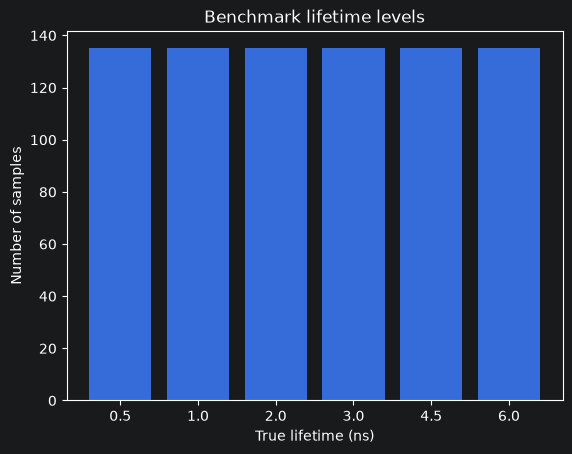

In [21]:
lifetime_counts = (
    pd.Series(
        benchmark_dataset.y
    )
    .value_counts()
    .sort_index()
)

plt.bar(
    lifetime_counts.index.astype(str),
    lifetime_counts.values,
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Number of samples")
plt.title("Benchmark lifetime levels")
plt.show()

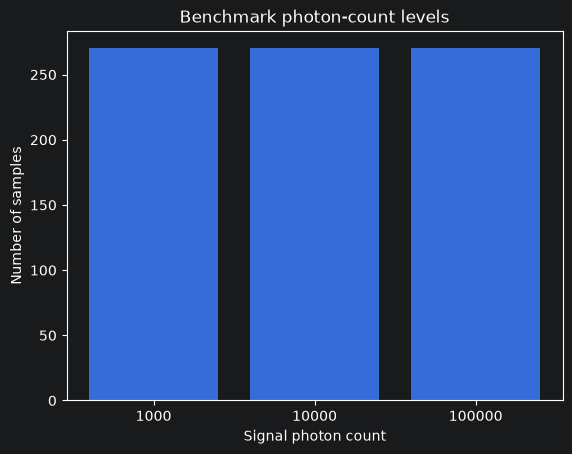

In [22]:
photon_counts = (
    benchmark_dataset.metadata[
        "signal_photon_count_target"
    ]
    .value_counts()
    .sort_index()
)

plt.bar(
    photon_counts.index.astype(str),
    photon_counts.values,
)

plt.xlabel("Signal photon count")
plt.ylabel("Number of samples")
plt.title("Benchmark photon-count levels")
plt.show()

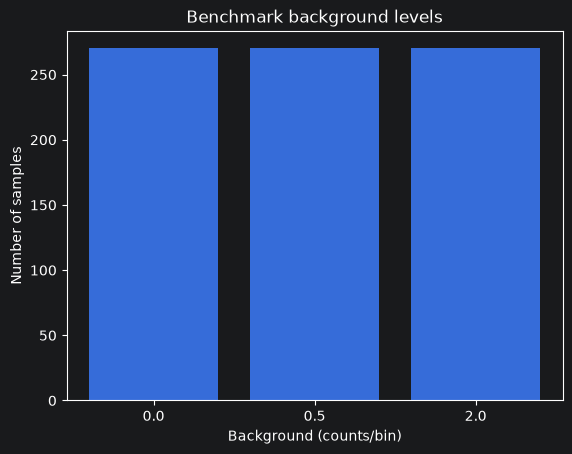

In [23]:
background_counts = (
    benchmark_dataset.metadata[
        "background_per_bin"
    ]
    .value_counts()
    .sort_index()
)

plt.bar(
    background_counts.index.astype(str),
    background_counts.values,
)

plt.xlabel("Background (counts/bin)")
plt.ylabel("Number of samples")
plt.title("Benchmark background levels")
plt.show()

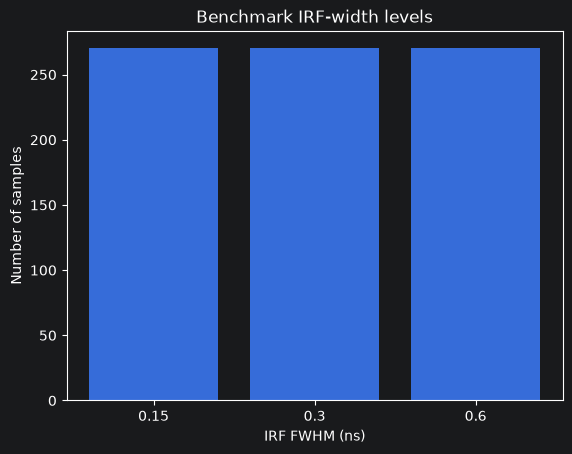

In [24]:
irf_width_counts = (
    benchmark_dataset.metadata[
        "irf_fwhm_ns"
    ]
    .value_counts()
    .sort_index()
)

plt.bar(
    irf_width_counts.index.astype(str),
    irf_width_counts.values,
)

plt.xlabel("IRF FWHM (ns)")
plt.ylabel("Number of samples")
plt.title("Benchmark IRF-width levels")
plt.show()

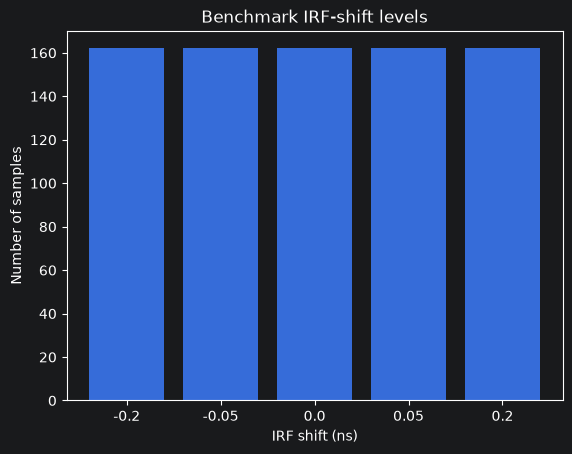

In [25]:
irf_shift_counts = (
    benchmark_dataset.metadata[
        "irf_shift_ns"
    ]
    .value_counts()
    .sort_index()
)

plt.bar(
    irf_shift_counts.index.astype(str),
    irf_shift_counts.values,
)

plt.xlabel("IRF shift (ns)")
plt.ylabel("Number of samples")
plt.title("Benchmark IRF-shift levels")
plt.show()

In [26]:
test_conditions = (
    benchmark_split.metadata_test.copy()
)

test_conditions[
    "true_lifetime_ns"
] = benchmark_split.y_test

test_conditions[
    [
        "sample_id",
        "true_lifetime_ns",
        "signal_photon_count_target",
        "background_per_bin",
        "irf_fwhm_ns",
        "irf_shift_ns",
    ]
].head(15)

,sample_id,true_lifetime_ns,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns
0,247,1.0,100000,0.5,0.30,0.00
1,670,4.5,100000,2.0,0.60,-0.20
2,227,1.0,100000,0.0,0.15,0.00
3,290,2.0,1000,0.5,0.30,-0.20
4,538,3.0,100000,2.0,0.60,0.05
5,796,6.0,100000,2.0,0.15,-0.05
6,198,1.0,10000,0.5,0.15,0.05
7,596,4.5,10000,0.0,0.60,-0.05
8,319,2.0,10000,0.0,0.15,0.20
9,569,4.5,1000,0.5,0.60,0.20


### Benchmark established

The final benchmark contains 810 synthetic TCSPC measurements spanning
controlled variation in lifetime, photon count, background, IRF width,
and IRF temporal shift.

A fixed 80/20 split produces 648 training samples and 162 test samples.
All physical parameter levels are represented in both subsets.

The same test samples and targets will be reused throughout the remaining
benchmark so that differences in performance can be attributed to the
estimator or input representation rather than to different evaluation
data.

## 2. Baseline lifetime estimators

Before evaluating machine-learning models, two simple reference
estimators are established.

### Constant-mean baseline

Every test sample receives the mean fluorescence lifetime of the
training set.

This estimator does not use the TCSPC histogram at all and therefore
defines a deliberately weak statistical reference.

### Mean-arrival-time estimator

A simple physics-inspired estimate is obtained from

$$
\hat{\tau}
=
t_{\mathrm{mean}} - t_{\mathrm{peak}}.
$$

This estimator uses timing information extracted from each histogram,
but does not explicitly model the IRF, background, or Poisson counting
statistics.

Both baselines are evaluated on exactly the same fixed test set used
throughout the remainder of the notebook.

In [27]:
baseline_results = evaluate_baselines(
    benchmark_split
)

baseline_results.keys()

dict_keys(['constant_mean', 'mean_arrival_time'])

In [28]:
baseline_summary = pd.DataFrame(
    [
        {
            "estimator": result.estimator_name,
            "mae_ns": result.metrics.mae_ns,
            "median_absolute_error_ns": (
                result.metrics.median_absolute_error_ns
            ),
            "rmse_ns": result.metrics.rmse_ns,
            "mean_relative_error_percent": (
                100.0
                * result.metrics.mean_relative_error
            ),
            "median_relative_error_percent": (
                100.0
                * result.metrics.median_relative_error
            ),
            "r2": result.metrics.r2,
        }
        for result in baseline_results.values()
    ]
)

baseline_summary

,estimator,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,median_relative_error_percent,r2
0,constant_mean,1.680327,1.678241,1.938794,132.525530,41.087963,-0.000892
1,mean_arrival_time,0.768455,0.470181,1.111604,50.815581,18.730105,0.670979


In [29]:
baseline_predictions = pd.DataFrame(
    {
        "true_lifetime_ns": (
            benchmark_split.y_test
        ),
        "constant_mean_ns": (
            baseline_results[
                "constant_mean"
            ].y_pred
        ),
        "mean_arrival_time_ns": (
            baseline_results[
                "mean_arrival_time"
            ].y_pred
        ),
    }
)

baseline_predictions.head(15)

,true_lifetime_ns,constant_mean_ns,mean_arrival_time_ns
0,1.0,2.821759,0.794631
1,4.5,2.821759,3.641715
2,1.0,2.821759,0.873227
3,2.0,2.821759,2.971504
4,3.0,2.821759,2.604650
5,6.0,2.821759,5.013641
6,1.0,2.821759,1.009608
7,4.5,2.821759,3.348302
8,2.0,2.821759,1.702602
9,4.5,2.821759,4.493009


In [30]:
baseline_diagnostics = pd.concat(
    [
        build_ml_prediction_diagnostics(
            split=benchmark_split,
            result=result,
        )
        for result in baseline_results.values()
    ],
    ignore_index=True,
)

In [31]:
baseline_diagnostics[
    [
        "estimator_name",
        "true_lifetime_ns",
        "predicted_lifetime_ns",
        "error_ns",
        "absolute_error_ns",
        "relative_error",
        "valid_estimate",
    ]
].head(10)

,estimator_name,true_lifetime_ns,predicted_lifetime_ns,error_ns,absolute_error_ns,relative_error,valid_estimate
0,constant_mean,1.0,2.821759,1.821759,1.821759,1.821759,True
1,constant_mean,4.5,2.821759,-1.678241,1.678241,0.372942,True
2,constant_mean,1.0,2.821759,1.821759,1.821759,1.821759,True
3,constant_mean,2.0,2.821759,0.821759,0.821759,0.410880,True
4,constant_mean,3.0,2.821759,-0.178241,0.178241,0.059414,True
5,constant_mean,6.0,2.821759,-3.178241,3.178241,0.529707,True
6,constant_mean,1.0,2.821759,1.821759,1.821759,1.821759,True
7,constant_mean,4.5,2.821759,-1.678241,1.678241,0.372942,True
8,constant_mean,2.0,2.821759,0.821759,0.821759,0.410880,True
9,constant_mean,4.5,2.821759,-1.678241,1.678241,0.372942,True


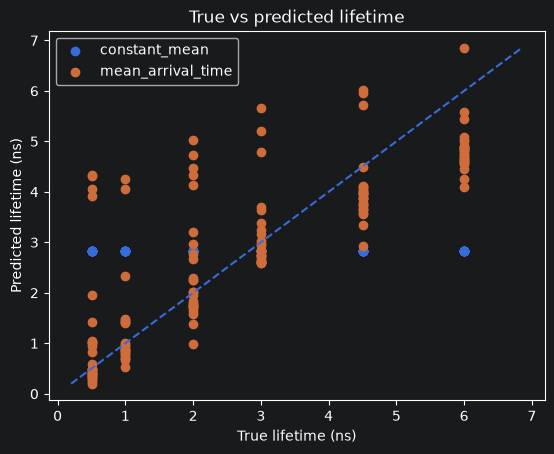

In [32]:
plot_true_vs_predicted(
    baseline_diagnostics
)

plt.show()

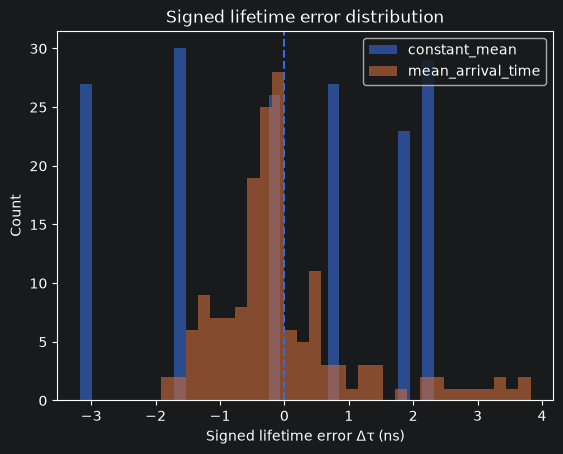

In [33]:
plot_error_histogram(
    baseline_diagnostics,
    bins=30,
)

plt.show()

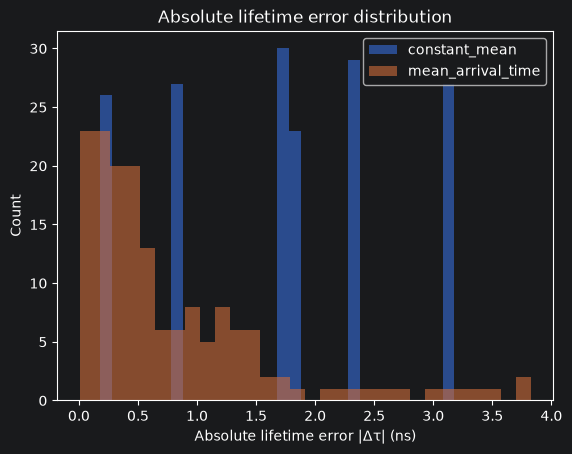

In [34]:
plot_error_histogram(
    baseline_diagnostics,
    absolute=True,
    bins=30,
)

plt.show()

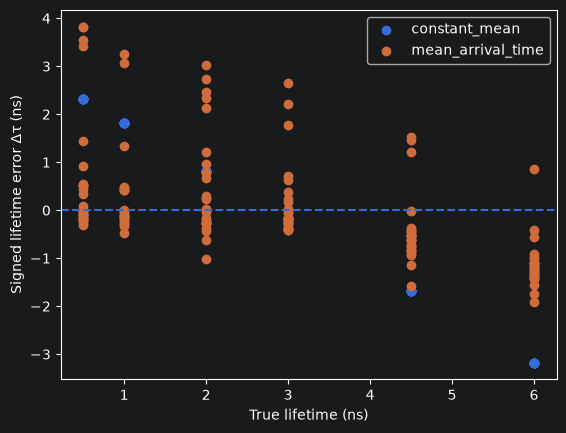

In [35]:
plot_error_vs_condition(
    baseline_diagnostics,
    condition_column="true_lifetime_ns",
)

plt.show()

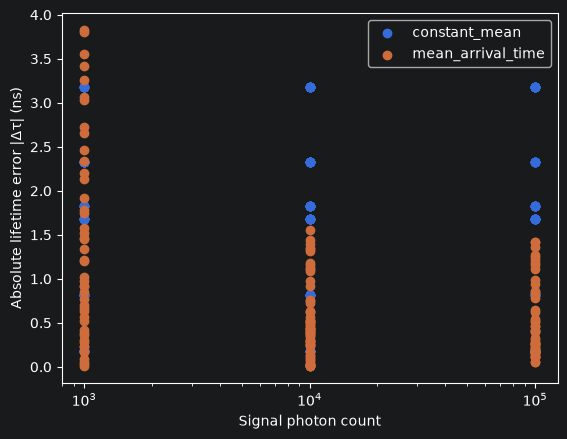

In [36]:
plot_error_vs_condition(
    baseline_diagnostics,
    condition_column=(
        "signal_photon_count_target"
    ),
    absolute=True,
    log_x=True,
)

plt.show()

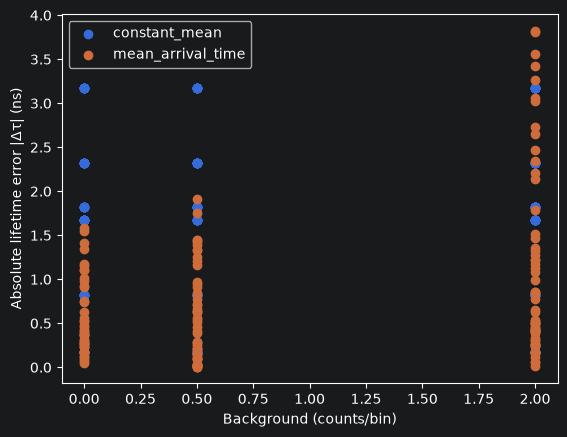

In [37]:
plot_error_vs_condition(
    baseline_diagnostics,
    condition_column="background_per_bin",
    absolute=True,
)

plt.show()

### Baseline observations

The two baseline estimators show clearly different levels of performance on
the final benchmark.

The **constant-mean baseline** provides essentially no predictive information
about an individual TCSPC histogram. It achieves an MAE of approximately
**1.68 ns** and $R^2 \approx 0$, as expected for an estimator that assigns
nearly the same lifetime to every test sample. Its signed error changes
systematically with lifetime: short lifetimes are overestimated, whereas
long lifetimes are underestimated.

The **mean-arrival-time estimator** performs substantially better. Its MAE
decreases to approximately **0.77 ns**, with a median absolute error of
approximately **0.47 ns** and $R^2 \approx 0.67$. The true-versus-predicted
plot confirms that the estimator captures a significant amount of
lifetime-dependent information from the histogram.

However, the remaining errors are strongly structured rather than purely
random. In particular, the mean-arrival estimator tends to overestimate
some short-lifetime curves and underestimate many long-lifetime curves.
Large positive errors also occur for some measurements with elevated
background.

Increasing the photon count from $10^3$ to $10^5$ does not produce a
simple monotonic reduction in error. Although the lowest-photon regime
contains some of the largest deviations, appreciable errors remain even at
high photon counts. This indicates that the estimator is limited not only
by photon-counting noise, but also by systematic effects such as background,
IRF broadening and temporal shift.

The background dependence is particularly clear: at the highest simulated
background level, the mean-arrival estimator exhibits a substantially wider
absolute-error range. This behaviour is physically expected because
background photons contribute throughout the acquisition window and shift
the measured mean arrival time toward later times.

Overall, the mean-arrival-time estimator provides a useful
physics-inspired baseline and captures considerably more lifetime
information than the constant predictor, but it does not adequately
separate fluorescence lifetime from nuisance effects. The following
sections therefore test whether trained estimators using the complete set
of engineered histogram features can learn this separation more
effectively.

## 3. Machine learning on engineered TCSPC features

The 15 physically engineered histogram features are now used as inputs
to three supervised regression models:

- Ridge regression,
- Random Forest regression,
- Histogram Gradient Boosting regression.

All models use exactly the same 648 training samples and 162 test samples.

The simulation metadata is not supplied to the models. The regressors
therefore have to infer lifetime from quantities that can be derived from
the measured histogram itself.

Ridge provides an approximately linear reference model, whereas Random
Forest and Histogram Gradient Boosting can learn nonlinear relationships
between the engineered features and fluorescence lifetime.

In [38]:
engineered_ml_results = {
    "ridge": evaluate_regressor(
        estimator_name="ridge",
        estimator=make_ridge_pipeline(),
        X_train=(
            benchmark_split.X_features_train
        ),
        y_train=benchmark_split.y_train,
        X_test=(
            benchmark_split.X_features_test
        ),
        y_test=benchmark_split.y_test,
    ),
    "random_forest": evaluate_regressor(
        estimator_name="random_forest",
        estimator=(
            make_random_forest_pipeline()
        ),
        X_train=(
            benchmark_split.X_features_train
        ),
        y_train=benchmark_split.y_train,
        X_test=(
            benchmark_split.X_features_test
        ),
        y_test=benchmark_split.y_test,
    ),
    "hist_gradient_boosting": (
        evaluate_regressor(
            estimator_name=(
                "hist_gradient_boosting"
            ),
            estimator=(
                make_hist_gradient_boosting_pipeline()
            ),
            X_train=(
                benchmark_split.X_features_train
            ),
            y_train=benchmark_split.y_train,
            X_test=(
                benchmark_split.X_features_test
            ),
            y_test=benchmark_split.y_test,
        )
    ),
}

In [39]:
engineered_ml_results.keys()

dict_keys(['ridge', 'random_forest', 'hist_gradient_boosting'])

In [40]:
engineered_ml_summary = pd.DataFrame(
    [
        {
            "estimator": result.estimator_name,
            "mae_ns": result.metrics.mae_ns,
            "median_absolute_error_ns": (
                result
                .metrics
                .median_absolute_error_ns
            ),
            "rmse_ns": result.metrics.rmse_ns,
            "mean_relative_error_percent": (
                100.0
                * result
                .metrics
                .mean_relative_error
            ),
            "median_relative_error_percent": (
                100.0
                * result
                .metrics
                .median_relative_error
            ),
            "r2": result.metrics.r2,
        }
        for result
        in engineered_ml_results.values()
    ]
)

engineered_ml_summary

,estimator,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,median_relative_error_percent,r2
0,ridge,0.282715,0.203984,0.410987,17.571449,8.339323,0.955024
1,random_forest,0.070185,0.000000,0.272166,2.375514,0.000000,0.980276
2,hist_gradient_boosting,0.090617,0.016158,0.224711,3.426658,0.738248,0.986555


In [41]:
baseline_and_ml_summary = pd.concat(
    [
        baseline_summary,
        engineered_ml_summary,
    ],
    ignore_index=True,
)

baseline_and_ml_summary = (
    baseline_and_ml_summary
    .sort_values(
        "mae_ns"
    )
    .reset_index(
        drop=True
    )
)

baseline_and_ml_summary

,estimator,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,median_relative_error_percent,r2
0,random_forest,0.070185,0.000000,0.272166,2.375514,0.000000,0.980276
1,hist_gradient_boosting,0.090617,0.016158,0.224711,3.426658,0.738248,0.986555
2,ridge,0.282715,0.203984,0.410987,17.571449,8.339323,0.955024
3,mean_arrival_time,0.768455,0.470181,1.111604,50.815581,18.730105,0.670979
4,constant_mean,1.680327,1.678241,1.938794,132.525530,41.087963,-0.000892


In [42]:
mean_arrival_mae = (
    baseline_results[
        "mean_arrival_time"
    ]
    .metrics
    .mae_ns
)

ml_improvement_rows = []

for (
    estimator_name,
    result,
) in engineered_ml_results.items():
    mae_ns = (
        result.metrics.mae_ns
    )

    reduction_percent = (
        100.0
        * (
            mean_arrival_mae
            - mae_ns
        )
        / mean_arrival_mae
    )

    ml_improvement_rows.append(
        {
            "estimator": estimator_name,
            "mae_ns": mae_ns,
            "mae_reduction_vs_mean_arrival_percent": (
                reduction_percent
            ),
        }
    )

ml_improvement_summary = pd.DataFrame(
    ml_improvement_rows
)

ml_improvement_summary

,estimator,mae_ns,mae_reduction_vs_mean_arrival_percent
0,ridge,0.282715,63.209976
1,random_forest,0.070185,90.866713
2,hist_gradient_boosting,0.090617,88.207869


In [43]:
engineered_ml_diagnostics = pd.concat(
    [
        build_ml_prediction_diagnostics(
            split=benchmark_split,
            result=result,
        )
        for result
        in engineered_ml_results.values()
    ],
    ignore_index=True,
)

In [44]:
engineered_ml_diagnostics[
    [
        "estimator_name",
        "true_lifetime_ns",
        "predicted_lifetime_ns",
        "error_ns",
        "absolute_error_ns",
        "relative_error",
    ]
].head(10)

,estimator_name,true_lifetime_ns,predicted_lifetime_ns,error_ns,absolute_error_ns,relative_error
0,ridge,1.0,1.038440,0.038440,0.038440,0.038440
1,ridge,4.5,4.289048,-0.210952,0.210952,0.046878
2,ridge,1.0,0.834365,-0.165635,0.165635,0.165635
3,ridge,2.0,1.828695,-0.171305,0.171305,0.085652
4,ridge,3.0,3.259178,0.259178,0.259178,0.086393
5,ridge,6.0,5.814806,-0.185194,0.185194,0.030866
6,ridge,1.0,0.898860,-0.101140,0.101140,0.101140
7,ridge,4.5,4.346305,-0.153695,0.153695,0.034154
8,ridge,2.0,2.293567,0.293567,0.293567,0.146783
9,ridge,4.5,4.479189,-0.020811,0.020811,0.004625


In [45]:
print(
    "Diagnostic rows:",
    engineered_ml_diagnostics.shape[0],
)

Diagnostic rows: 486


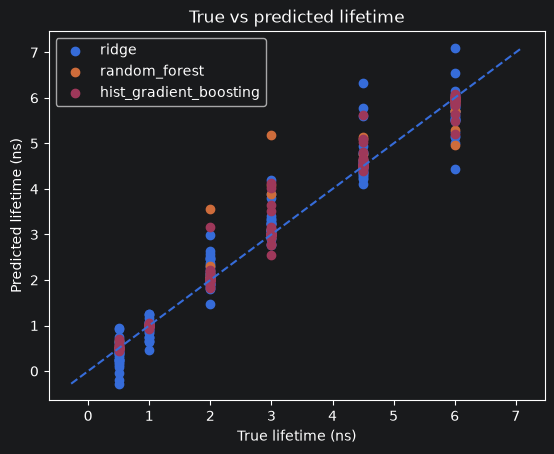

In [46]:
plot_true_vs_predicted(
    engineered_ml_diagnostics
)

plt.show()

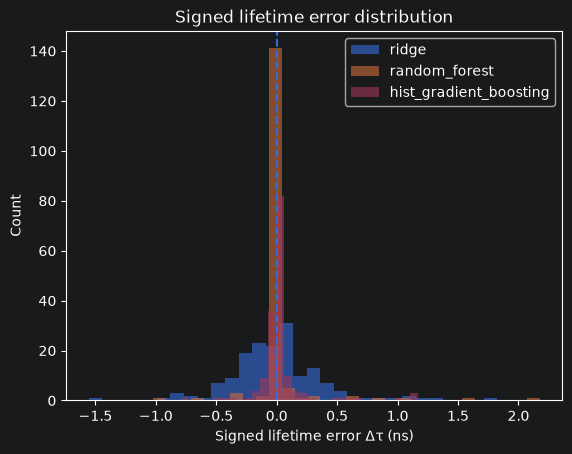

In [47]:
plot_error_histogram(
    engineered_ml_diagnostics,
    bins=30,
)

plt.show()

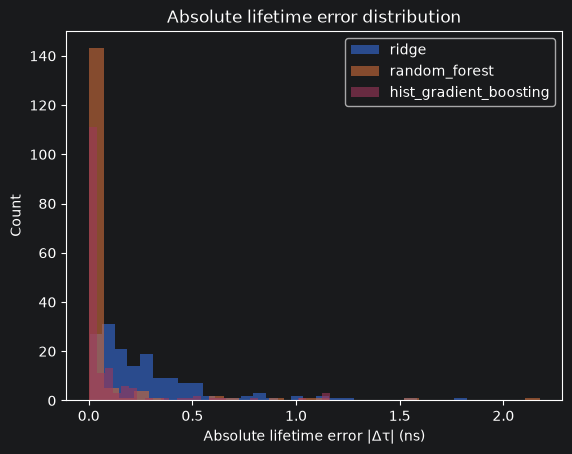

In [48]:
plot_error_histogram(
    engineered_ml_diagnostics,
    absolute=True,
    bins=30,
)

plt.show()

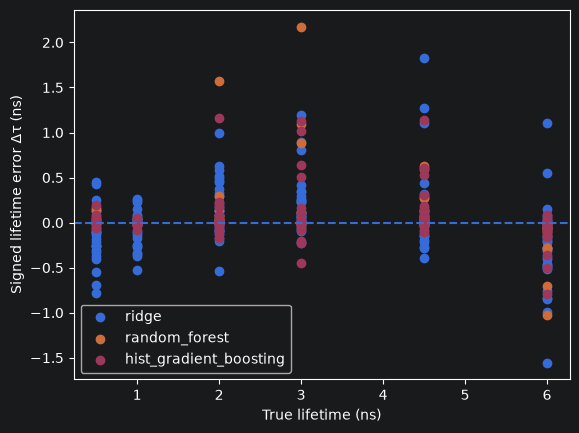

In [49]:
plot_error_vs_condition(
    engineered_ml_diagnostics,
    condition_column="true_lifetime_ns",
)

plt.show()

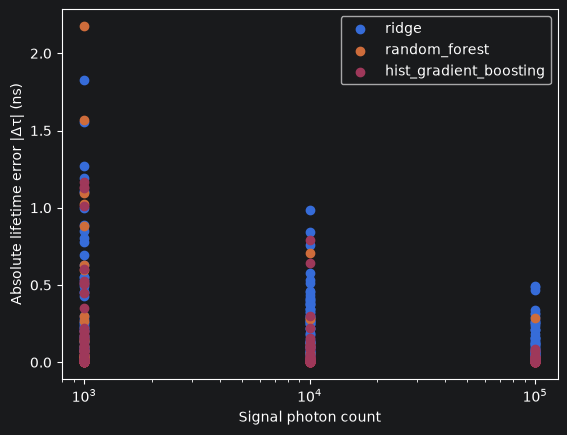

In [50]:
plot_error_vs_condition(
    engineered_ml_diagnostics,
    condition_column=(
        "signal_photon_count_target"
    ),
    absolute=True,
    log_x=True,
)

plt.show()

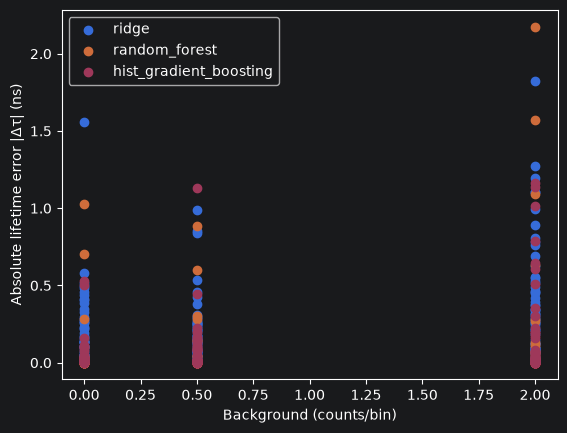

In [51]:
plot_error_vs_condition(
    engineered_ml_diagnostics,
    condition_column="background_per_bin",
    absolute=True,
)

plt.show()

In [52]:
baseline_and_ml_diagnostics = pd.concat(
    [
        baseline_diagnostics.loc[
            baseline_diagnostics[
                "estimator_name"
            ]
            == "mean_arrival_time"
        ],
        engineered_ml_diagnostics,
    ],
    ignore_index=True,
)

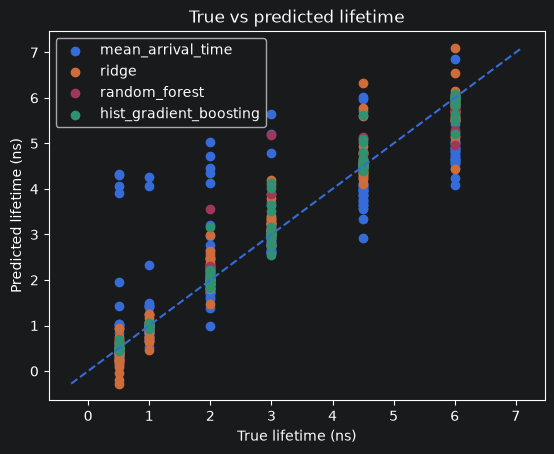

In [53]:
plot_true_vs_predicted(
    baseline_and_ml_diagnostics
)

plt.show()

### Engineered-feature ML observations

All three supervised regressors substantially outperform the
physics-inspired mean-arrival-time estimator when given the full set of
engineered histogram features.

**Random Forest gives the lowest MAE**, approximately **0.070 ns**, corresponding
to a reduction of about **90.9%** relative to the mean-arrival baseline.
Histogram Gradient Boosting performs similarly, with an MAE of approximately
**0.091 ns** and an **88.2%** reduction relative to mean arrival time.
Ridge regression is less accurate, but still improves the MAE from
approximately **0.77 ns to 0.28 ns**, a reduction of about **63.2%**.

The corresponding $R^2$ values are approximately

$$
R^2_{\mathrm{Ridge}} = 0.955,\qquad
R^2_{\mathrm{RF}} = 0.980,\qquad
R^2_{\mathrm{HGB}} = 0.987.
$$

Thus, even the linear Ridge model captures most of the lifetime variation
once the histogram has been transformed into physically meaningful
features. The additional improvement from Random Forest and Histogram
Gradient Boosting indicates that the relationship between these features
and fluorescence lifetime is substantially nonlinear.

The error distributions reinforce this picture. Ridge produces a relatively
broad distribution centred near zero, whereas the two nonlinear models
produce a strong concentration of predictions close to the correct lifetime.
Random Forest has a median absolute error of effectively zero on this test
set, while Histogram Gradient Boosting has a median absolute error of only
about **0.016 ns**. Nevertheless, all three models retain occasional
large-error outliers, so aggregate performance alone does not describe the
full operating behaviour.

The photon-count dependence is particularly clear. The largest errors occur
predominantly in the $10^3$-photon regime. At $10^4$ photons the error
range contracts substantially, and at $10^5$ photons the nonlinear models
are very frequently close to the correct lifetime. In contrast to the
mean-arrival estimator, the trained models therefore show a much clearer
improvement with increasing photon statistics.

Background remains an important nuisance variable. Increasing the background
to **2 counts/bin** broadens the error distribution and produces some of the
largest remaining outliers. However, most Random Forest and Histogram
Gradient Boosting predictions remain close to the true lifetime even at this
background level. This suggests that the collection of engineered features
contains enough complementary information for nonlinear models to compensate
for background effects much more effectively than mean arrival time alone.

The true-versus-predicted comparison also shows that the engineered-feature
models follow the ideal $\hat{\tau}=\tau$ relationship far more closely
than the mean-arrival estimator across the full 0.5–6 ns lifetime range.
Ridge retains visibly greater scatter, while Random Forest and Histogram
Gradient Boosting form much tighter prediction clusters.

An important qualification is that this benchmark uses a random train/test
split of a factorial dataset. The training and test sets therefore contain
the **same six lifetime levels** while differing in the individual simulated
measurements and nuisance-condition combinations. The very small errors of
the nonlinear models should consequently be interpreted as strong robustness
across photon count, background, IRF width and IRF shift at familiar lifetime
levels, rather than as evidence that the models would necessarily generalize
equally well to completely unseen lifetime values.

Overall, the results demonstrate that physically engineered TCSPC features
capture substantially more useful lifetime information than the
mean-arrival-time estimator alone, and that nonlinear regression can exploit
this representation particularly effectively. The next question is whether
these engineered features are actually the best representation, or whether
comparable or better performance can be obtained directly from normalized
histogram bins or PCA-compressed histograms.

## 4. Representation benchmark

The previous section showed that nonlinear regressors can estimate lifetime
very accurately from physically engineered histogram features.

The next question is whether this performance depends on the engineered
representation itself.

Three input representations are compared:

1. **Engineered features** — 15 physically interpretable quantities
   extracted from each histogram.
2. **TOTAL-normalized histogram** — all 400 histogram bins after division
   by the measured total count.
3. **PCA-compressed normalized histogram** — a lower-dimensional
   representation learned from the normalized training histograms.

The primary controlled comparison uses **Ridge regression for all three
representations**. Keeping the estimator family fixed isolates the effect
of the representation.

The same training samples, test samples, and lifetime targets are used in
every comparison.

In [54]:
N_PCA_COMPONENTS = 10

histogram_representations = (
    build_histogram_representations(
        benchmark_split,
        n_pca_components=N_PCA_COMPONENTS,
    )
)

In [55]:
print(
    "Engineered train:",
    benchmark_split.X_features_train.shape,
)

print(
    "Normalized histogram train:",
    histogram_representations
    .X_normalized_train.shape,
)

print(
    "PCA train:",
    histogram_representations
    .X_pca_train.shape,
)

print(
    "Engineered test:",
    benchmark_split.X_features_test.shape,
)

print(
    "Normalized histogram test:",
    histogram_representations
    .X_normalized_test.shape,
)

print(
    "PCA test:",
    histogram_representations
    .X_pca_test.shape,
)

Engineered train: (648, 15)
Normalized histogram train: (648, 400)
PCA train: (648, 10)
Engineered test: (162, 15)
Normalized histogram test: (162, 400)
PCA test: (162, 10)


In [56]:
normalized_train_totals = (
    histogram_representations
    .X_normalized_train
    .sum(
        axis=1
    )
)

normalized_test_totals = (
    histogram_representations
    .X_normalized_test
    .sum(
        axis=1
    )
)

print(
    "Training totals:",
    normalized_train_totals.min(),
    normalized_train_totals.max(),
)

print(
    "Test totals:",
    normalized_test_totals.min(),
    normalized_test_totals.max(),
)

Training totals: 0.9999999999999998 1.0000000000000002
Test totals: 0.9999999999999998 1.0000000000000002


In [57]:
assert np.allclose(
    normalized_train_totals,
    1.0,
)

assert np.allclose(
    normalized_test_totals,
    1.0,
)

TOTAL normalization removes the absolute scale of each histogram:

$$
x_i^{(\mathrm{norm})}
=
\frac{x_i}
{\sum_j x_j}.
$$

Consequently, a 1,000-photon histogram and a 100,000-photon histogram with
the same normalized temporal shape can become very similar representations.

This may be beneficial if total intensity is treated as a nuisance scale,
but it also removes information about photon statistics and therefore about
measurement uncertainty.

In [58]:
pca_cumulative_variance = (
    cumulative_explained_variance(
        histogram_representations.pca
    )
)

In [59]:
pca_variance_summary = pd.DataFrame(
    {
        "principal_component": np.arange(
            1,
            N_PCA_COMPONENTS + 1,
        ),
        "explained_variance_ratio": (
            histogram_representations
            .pca
            .explained_variance_ratio_
        ),
        "cumulative_explained_variance": (
            pca_cumulative_variance
        ),
    }
)

pca_variance_summary

,principal_component,explained_variance_ratio,cumulative_explained_variance
0,1,0.670913,0.670913
1,2,0.155599,0.826512
2,3,0.051412,0.877924
3,4,0.032884,0.910808
4,5,0.007921,0.918729
5,6,0.006624,0.925352
6,7,0.003820,0.929172
7,8,0.003464,0.932637
8,9,0.002230,0.934866
9,10,0.001843,0.936710


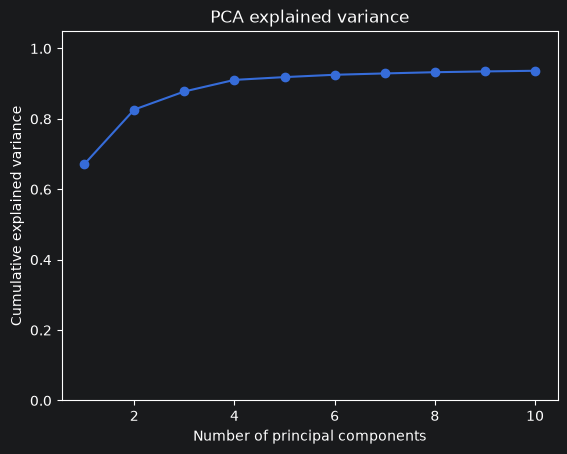

In [60]:
plt.plot(
    pca_variance_summary[
        "principal_component"
    ],
    pca_variance_summary[
        "cumulative_explained_variance"
    ],
    marker="o",
)

plt.xlabel(
    "Number of principal components"
)

plt.ylabel(
    "Cumulative explained variance"
)

plt.title(
    "PCA explained variance"
)

plt.ylim(
    0.0,
    1.05,
)

plt.show()

In [61]:
ridge_representation_results = (
    evaluate_ridge_representation_benchmark(
        benchmark_split,
        histogram_representations,
    )
)

In [62]:
ridge_representation_results.keys()

dict_keys(['engineered_features', 'normalized_histogram', 'pca_histogram'])

In [63]:
ridge_representation_summary = (
    pd.DataFrame(
        [
            {
                "representation": (
                    representation_name
                ),
                "estimator": (
                    result.estimator_name
                ),
                "n_features": (
                    {
                        "engineered_features": 15,
                        "normalized_histogram": (
                            benchmark_split
                            .X_histograms_train
                            .shape[1]
                        ),
                        "pca_histogram": (
                            N_PCA_COMPONENTS
                        ),
                    }[
                        representation_name
                    ]
                ),
                "mae_ns": (
                    result.metrics.mae_ns
                ),
                "median_absolute_error_ns": (
                    result
                    .metrics
                    .median_absolute_error_ns
                ),
                "rmse_ns": (
                    result.metrics.rmse_ns
                ),
                "mean_relative_error_percent": (
                    100.0
                    * result
                    .metrics
                    .mean_relative_error
                ),
                "r2": (
                    result.metrics.r2
                ),
            }
            for (
                representation_name,
                result,
            )
            in ridge_representation_results.items()
        ]
    )
    .sort_values(
        "mae_ns"
    )
    .reset_index(
        drop=True
    )
)

ridge_representation_summary

,representation,estimator,n_features,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,r2
0,engineered_features,ridge_engineered_features,15,0.282715,0.203984,0.410987,17.571449,0.955024
1,normalized_histogram,ridge_normalized_histogram,400,0.454679,0.245133,0.739751,26.153270,0.854288
2,pca_histogram,ridge_pca_histogram,10,0.566339,0.461143,0.731331,38.788470,0.857586


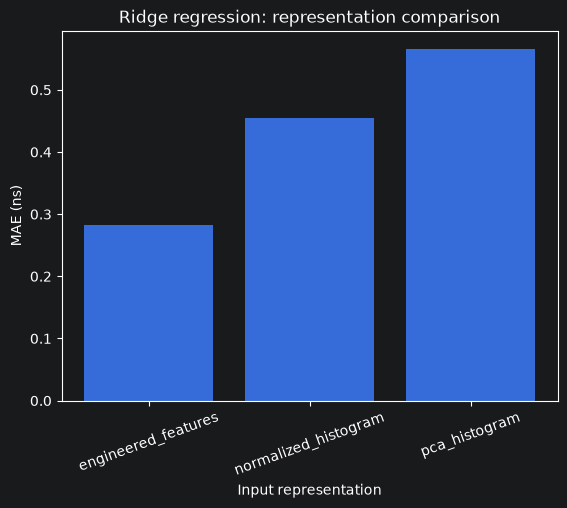

In [64]:
plt.bar(
    ridge_representation_summary[
        "representation"
    ],
    ridge_representation_summary[
        "mae_ns"
    ],
)

plt.ylabel(
    "MAE (ns)"
)

plt.xlabel(
    "Input representation"
)

plt.title(
    "Ridge regression: representation comparison"
)

plt.xticks(
    rotation=20,
)

plt.show()

In [65]:
ridge_representation_diagnostics = (
    pd.concat(
        [
            build_ml_prediction_diagnostics(
                split=benchmark_split,
                result=result,
            )
            for result
            in ridge_representation_results.values()
        ],
        ignore_index=True,
    )
)

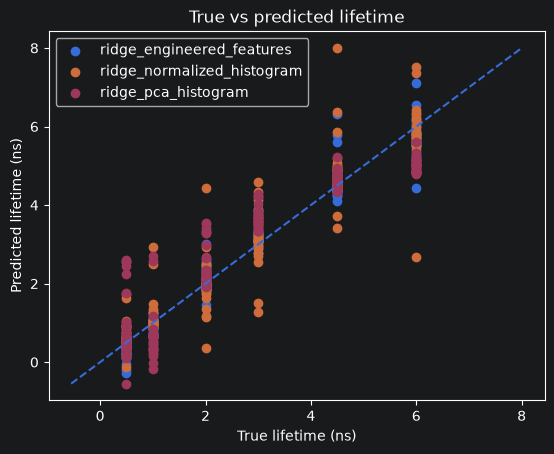

In [66]:
plot_true_vs_predicted(
    ridge_representation_diagnostics
)

plt.show()

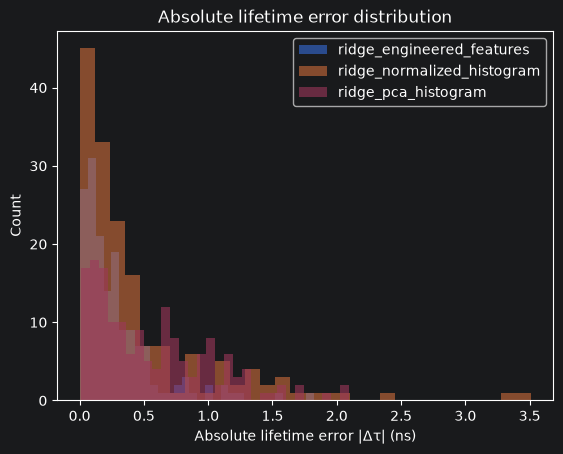

In [67]:
plot_error_histogram(
    ridge_representation_diagnostics,
    absolute=True,
    bins=30,
)

plt.show()

In [68]:
nonlinear_representation_results = (
    evaluate_nonlinear_representation_benchmark(
        benchmark_split,
        histogram_representations,
    )
)

In [69]:
nonlinear_representation_rows = []

for (
    model_name,
    model_results,
) in nonlinear_representation_results.items():
    for (
        representation_name,
        result,
    ) in model_results.items():
        nonlinear_representation_rows.append(
            {
                "model": model_name,
                "representation": (
                    representation_name
                ),
                "mae_ns": (
                    result.metrics.mae_ns
                ),
                "median_absolute_error_ns": (
                    result
                    .metrics
                    .median_absolute_error_ns
                ),
                "rmse_ns": (
                    result.metrics.rmse_ns
                ),
                "mean_relative_error_percent": (
                    100.0
                    * result
                    .metrics
                    .mean_relative_error
                ),
                "r2": (
                    result.metrics.r2
                ),
            }
        )

nonlinear_representation_summary = (
    pd.DataFrame(
        nonlinear_representation_rows
    )
    .sort_values(
        [
            "model",
            "mae_ns",
        ]
    )
    .reset_index(
        drop=True
    )
)

nonlinear_representation_summary

,model,representation,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,r2
0,hist_gradient_boosting,engineered_features,0.090617,0.016158,0.224711,3.426658,0.986555
1,hist_gradient_boosting,pca_histogram,0.145095,0.036966,0.305933,6.002902,0.975078
2,hist_gradient_boosting,normalized_histogram,0.207537,0.041986,0.430159,7.728886,0.950730
3,random_forest,engineered_features,0.070185,0.000000,0.272166,2.375514,0.980276
4,random_forest,pca_histogram,0.124444,0.000000,0.328604,4.040295,0.971248
5,random_forest,normalized_histogram,0.214969,0.025000,0.460840,8.782407,0.943451


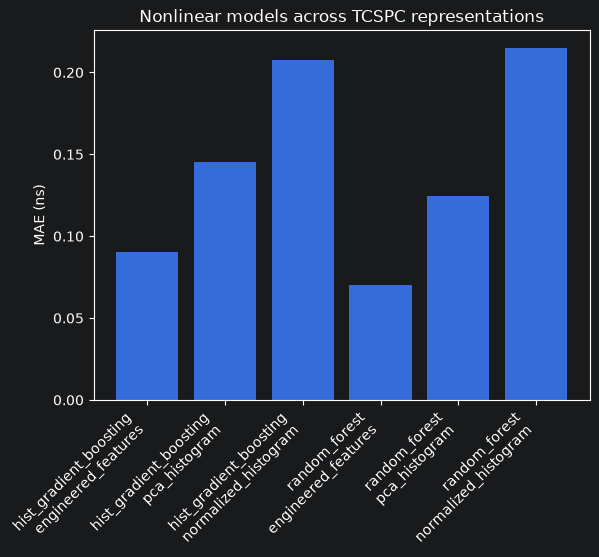

In [70]:
representation_plot_table = (
    nonlinear_representation_summary.copy()
)

representation_plot_table[
    "model_representation"
] = (
    representation_plot_table[
        "model"
    ]
    + "\n"
    + representation_plot_table[
        "representation"
    ]
)

plt.bar(
    representation_plot_table[
        "model_representation"
    ],
    representation_plot_table[
        "mae_ns"
    ],
)

plt.ylabel(
    "MAE (ns)"
)

plt.title(
    "Nonlinear models across TCSPC representations"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.show()

In [71]:
photon_count_ablation_results = (
    evaluate_photon_count_ablation(
        benchmark_split,
        histogram_representations,
    )
)

In [72]:
photon_count_ablation_summary = (
    pd.DataFrame(
        [
            {
                "representation": (
                    representation_name
                ),
                "mae_ns": (
                    result.metrics.mae_ns
                ),
                "median_absolute_error_ns": (
                    result
                    .metrics
                    .median_absolute_error_ns
                ),
                "rmse_ns": (
                    result.metrics.rmse_ns
                ),
                "mean_relative_error_percent": (
                    100.0
                    * result
                    .metrics
                    .mean_relative_error
                ),
                "r2": (
                    result.metrics.r2
                ),
            }
            for (
                representation_name,
                result,
            )
            in photon_count_ablation_results.items()
        ]
    )
    .sort_values(
        "mae_ns"
    )
    .reset_index(
        drop=True
    )
)

photon_count_ablation_summary

,representation,mae_ns,median_absolute_error_ns,rmse_ns,mean_relative_error_percent,r2
0,normalized_histogram_with_total_counts,0.454141,0.238809,0.740669,26.292048,0.853926
1,normalized_histogram,0.454679,0.245133,0.739751,26.153270,0.854288
2,pca_histogram_with_total_counts,0.550408,0.477916,0.713855,37.467797,0.864311
3,pca_histogram,0.566339,0.461143,0.731331,38.788470,0.857586


In [73]:
normalized_mae = (
    photon_count_ablation_results[
        "normalized_histogram"
    ]
    .metrics
    .mae_ns
)

normalized_with_counts_mae = (
    photon_count_ablation_results[
        "normalized_histogram_with_total_counts"
    ]
    .metrics
    .mae_ns
)

pca_mae = (
    photon_count_ablation_results[
        "pca_histogram"
    ]
    .metrics
    .mae_ns
)

pca_with_counts_mae = (
    photon_count_ablation_results[
        "pca_histogram_with_total_counts"
    ]
    .metrics
    .mae_ns
)

count_ablation_effect = pd.DataFrame(
    [
        {
            "representation": (
                "normalized_histogram"
            ),
            "mae_without_counts_ns": (
                normalized_mae
            ),
            "mae_with_counts_ns": (
                normalized_with_counts_mae
            ),
            "mae_change_percent": (
                100.0
                * (
                    normalized_with_counts_mae
                    - normalized_mae
                )
                / normalized_mae
            ),
        },
        {
            "representation": (
                "pca_histogram"
            ),
            "mae_without_counts_ns": (
                pca_mae
            ),
            "mae_with_counts_ns": (
                pca_with_counts_mae
            ),
            "mae_change_percent": (
                100.0
                * (
                    pca_with_counts_mae
                    - pca_mae
                )
                / pca_mae
            ),
        },
    ]
)

count_ablation_effect

,representation,mae_without_counts_ns,mae_with_counts_ns,mae_change_percent
0,normalized_histogram,0.454679,0.454141,-0.118247
1,pca_histogram,0.566339,0.550408,-2.813002


### Representation-benchmark observations

The representation benchmark shows that the choice of input representation
has a substantial effect on lifetime-estimation performance, even when the
training samples, test samples, targets, and estimator family are held fixed.

The controlled **Ridge comparison** gives the clearest result. Ridge regression
performs best with the physically engineered features, reaching an MAE of
approximately **0.283 ns**. Using the complete 400-bin TOTAL-normalized
histogram increases the MAE to approximately **0.455 ns**, while the
10-component PCA representation performs worst in this linear comparison,
with an MAE of approximately **0.566 ns**.

Thus, the 15 engineered features provide a considerably more efficient
representation for approximately linear lifetime estimation than either
the full normalized histogram or its PCA compression. The engineered
features appear to concentrate lifetime-relevant structure into quantities
that are much easier for a linear estimator to exploit.

The PCA analysis provides an important qualification. The first principal
component alone explains approximately **67%** of the variance among the
normalized histograms, the first two explain approximately **83%**, and
10 components retain approximately **93.7%** of the total variance.
Nevertheless, the 10-component PCA representation does not outperform the
engineered features and, for Ridge, does not even outperform the complete
normalized histogram.

This illustrates an important distinction:

$$
\text{high explained histogram variance}
\neq
\text{high lifetime-predictive information}.
$$

PCA is unsupervised and therefore identifies directions that explain
variation in histogram shape regardless of whether that variation originates
from lifetime, background, IRF width, IRF shift, photon noise, or another
source. Retaining most of the total histogram variance therefore does not
guarantee that the retained components provide the most convenient
coordinates for lifetime regression.

The nonlinear-model comparison leads to a similar overall conclusion.
For both Random Forest and Histogram Gradient Boosting, the engineered
features remain the strongest representation. Their MAEs are approximately
**0.070 ns** and **0.091 ns**, respectively.

However, an interesting change appears between the two histogram-based
representations. With nonlinear models, PCA compression becomes clearly
better than using all 400 normalized histogram bins directly. Random Forest
improves from approximately **0.215 ns** with the normalized histogram to
**0.124 ns** with PCA, while Histogram Gradient Boosting improves from
approximately **0.208 ns** to **0.145 ns**.

This suggests that PCA can still be useful even though it is not itself
lifetime-aware. Reducing 400 correlated histogram bins to 10 dominant
components appears to provide a more compact and less redundant input space
for the nonlinear estimators. In this sense, PCA acts as a useful
dimensionality-reduction step, but it still does not match the explicitly
physics-informed engineered representation.

The photon-count ablation produces a different result. Restoring the measured
total photon count after TOTAL normalization changes the Ridge performance
only slightly. For the full normalized histogram, the MAE decreases from
approximately **0.4547 ns to 0.4541 ns**, an improvement of only about
**0.1%**. For the PCA representation, the MAE decreases from approximately
**0.566 ns to 0.550 ns**, corresponding to an improvement of about **2.8%**.

Therefore, absolute photon count contains some additional information, but
its contribution is small in this particular Ridge benchmark. The much larger
performance difference between engineered features and normalized histogram
representations cannot be explained simply by the engineered representation
retaining total-count information. Rather, the engineered features appear to
encode lifetime-sensitive temporal structure more directly.

Overall, the representation benchmark supports three main conclusions:

1. **Physics-informed engineered features are the most effective
   representation in this benchmark**, for both linear and nonlinear
   estimators.
2. **PCA preserves most histogram variance but not necessarily the most
   lifetime-relevant information**; nevertheless, its dimensionality
   reduction substantially helps the nonlinear models relative to the full
   400-bin normalized histogram.
3. **Removing absolute photon-count scale is not the dominant reason for the
   weaker performance of normalized histograms**, because restoring measured
   total counts produces only a modest improvement.

The next comparison therefore retains the engineered-feature ML models as the
strong data-driven estimators and places them against the physically explicit
classical reconvolution fit.

## 5. Classical reconvolution versus engineered-feature ML

The engineered-feature machine-learning estimators are now compared with
the physically explicit mono-exponential reconvolution fit developed
earlier in the toolkit.

The classical model fits four parameters independently for every test
histogram:

- fluorescence amplitude,
- fluorescence lifetime,
- stationary background,
- temporal IRF shift.

A Poisson likelihood objective is used.

The classical benchmark uses a fixed nominal Gaussian IRF with
FWHM = 0.30 ns. Temporal IRF shift is fitted independently for each curve.

Because the simulated benchmark contains IRF widths of 0.15, 0.30, and
0.60 ns, the nominal-IRF fit is exactly matched in width for the 0.30 ns
subset and deliberately tests robustness to IRF-width mismatch for the
narrower and broader subsets.

This corresponds to a realistic fixed-calibration setting in which the
classical estimator assumes a nominal instrument response, whereas the
machine-learning models have been trained across the complete range of
simulated IRF conditions.

Classical fitting failures are retained explicitly rather than discarded.
Error statistics are calculated only over valid classical fits, while the
failure rate is reported separately.

In [74]:
NOMINAL_IRF_FWHM_NS = 0.30

nominal_irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre_ns,
    fwhm=NOMINAL_IRF_FWHM_NS,
)

nominal_irf = normalize_irf(
    time=time,
    irf=nominal_irf,
)

In [75]:
print(
    "Nominal IRF FWHM:",
    NOMINAL_IRF_FWHM_NS,
    "ns",
)

print(
    "IRF integral:",
    np.trapezoid(
        nominal_irf,
        x=time,
    ),
)

Nominal IRF FWHM: 0.3 ns
IRF integral: 1.0


In [76]:
TEMPORAL_SHIFT_BOUNDS = (
    -0.5,
    0.5,
)

CLASSICAL_OBJECTIVE = "poisson"

In [77]:
classical_result = (
    evaluate_reconvolution_benchmark(
        time=time,
        X_histograms=(
            benchmark_split.X_histograms_test
        ),
        y_true=benchmark_split.y_test,
        metadata=benchmark_split.metadata_test,
        irf=nominal_irf,
        temporal_shift_bounds=(
            TEMPORAL_SHIFT_BOUNDS
        ),
        objective=CLASSICAL_OBJECTIVE,
    )
)

In [78]:
classical_summary = pd.DataFrame(
    [
        {
            "n_samples": (
                classical_result
                .summary
                .n_samples
            ),
            "n_successful_fits": (
                classical_result
                .summary
                .n_successful_fits
            ),
            "n_failed_fits": (
                classical_result
                .summary
                .n_failed_fits
            ),
            "success_rate_percent": (
                100.0
                * classical_result
                .summary
                .success_rate
            ),
            "failure_rate_percent": (
                100.0
                * classical_result
                .summary
                .failure_rate
            ),
            "mae_valid_ns": (
                classical_result
                .summary
                .mae_valid_ns
            ),
            "median_absolute_error_valid_ns": (
                classical_result
                .summary
                .median_absolute_error_valid_ns
            ),
            "rmse_valid_ns": (
                classical_result
                .summary
                .rmse_valid_ns
            ),
            "mean_runtime_ms": (
                classical_result
                .summary
                .mean_runtime_ms
            ),
            "median_runtime_ms": (
                classical_result
                .summary
                .median_runtime_ms
            ),
        }
    ]
)

classical_summary

,n_samples,n_successful_fits,n_failed_fits,success_rate_percent,failure_rate_percent,mae_valid_ns,median_absolute_error_valid_ns,rmse_valid_ns,mean_runtime_ms,median_runtime_ms
0,162,162,0,100.0,0.0,0.140721,0.079069,0.256241,51.067471,46.1183


In [79]:
classical_result.per_curve[
    [
        "sample_id",
        "true_lifetime_ns",
        "fitted_lifetime_ns",
        "error_ns",
        "absolute_error_ns",
        "fitted_background",
        "fitted_temporal_shift_ns",
        "valid_fit",
        "boundary_hit",
        "poisson_deviance",
        "runtime_ms",
    ]
].head(15)

,sample_id,true_lifetime_ns,fitted_lifetime_ns,error_ns,absolute_error_ns,fitted_background,fitted_temporal_shift_ns,valid_fit,boundary_hit,poisson_deviance,runtime_ms
0,247.0,1.0,0.878251,-0.121749,0.121749,7.975255e-01,1.994870e-02,True,False,3114.916177,27.5993
1,670.0,4.5,4.441067,-0.058933,0.058933,8.878310e+00,-2.769942e-01,True,False,1352.618787,80.0084
2,227.0,1.0,0.912651,-0.087349,0.087349,4.489680e-04,4.719910e-02,True,False,3207.766862,15.4339
3,290.0,2.0,2.068712,0.068712,0.068712,4.686354e-01,-1.739477e-01,True,False,380.079658,29.9313
4,538.0,3.0,3.101833,0.101833,0.101833,4.028872e+00,-5.828086e-02,True,False,2240.218513,79.4133
5,796.0,6.0,4.429995,-1.570005,1.570005,4.349938e+01,1.933025e-08,True,False,3062.027321,43.6365
6,198.0,1.0,0.956979,-0.043021,0.043021,4.568158e-01,8.853714e-02,True,False,581.365535,18.6816
7,596.0,4.5,4.483311,-0.016689,0.016689,5.310068e-01,-1.278374e-01,True,False,572.686698,62.6166
8,319.0,2.0,1.949344,-0.050656,0.050656,1.000000e-12,2.294782e-01,True,True,447.615826,51.4411
9,569.0,4.5,4.693373,0.193373,0.193373,5.564404e-01,7.273356e-02,True,False,415.671025,18.7158


In [80]:
print(
    "Valid fits:",
    classical_result
    .summary
    .n_successful_fits,
)

print(
    "Failed fits:",
    classical_result
    .summary
    .n_failed_fits,
)

print(
    "Boundary hits:",
    classical_result
    .per_curve[
        "boundary_hit"
    ]
    .sum(),
)

Valid fits: 162
Failed fits: 0
Boundary hits: 22


In [81]:
classical_result.per_curve[
    "failure_reason"
].value_counts(
    dropna=False
)

failure_reason
None    162
Name: count, dtype: int64

In [82]:
comparison_rows = []

for (
    estimator_name,
    result,
) in engineered_ml_results.items():

    errors = (
        result.y_pred
        - benchmark_split.y_test
    )

    comparison_rows.append(
        {
            "estimator": estimator_name,
            "n_test": (
                benchmark_split.y_test.size
            ),
            "n_valid": (
                benchmark_split.y_test.size
            ),
            "failure_rate_percent": 0.0,
            "mae_ns": (
                result.metrics.mae_ns
            ),
            "median_absolute_error_ns": (
                result
                .metrics
                .median_absolute_error_ns
            ),
            "rmse_ns": (
                result.metrics.rmse_ns
            ),
            "bias_ns": float(
                np.mean(
                    errors
                )
            ),
        }
    )

In [83]:
classical_valid_mask = (
    classical_result.per_curve[
        "valid_fit"
    ].to_numpy(
        dtype=bool
    )
)

classical_valid_errors = (
    classical_result.per_curve.loc[
        classical_valid_mask,
        "error_ns",
    ]
    .to_numpy(
        dtype=np.float64
    )
)

comparison_rows.append(
    {
        "estimator": (
            "classical_reconvolution"
        ),
        "n_test": (
            classical_result
            .summary
            .n_samples
        ),
        "n_valid": (
            classical_result
            .summary
            .n_successful_fits
        ),
        "failure_rate_percent": (
            100.0
            * classical_result
            .summary
            .failure_rate
        ),
        "mae_ns": (
            classical_result
            .summary
            .mae_valid_ns
        ),
        "median_absolute_error_ns": (
            classical_result
            .summary
            .median_absolute_error_valid_ns
        ),
        "rmse_ns": (
            classical_result
            .summary
            .rmse_valid_ns
        ),
        "bias_ns": (
            float(
                np.mean(
                    classical_valid_errors
                )
            )
            if classical_valid_errors.size
            > 0
            else np.nan
        ),
    }
)

In [84]:
classical_vs_ml_summary = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        "mae_ns"
    )
    .reset_index(
        drop=True
    )
)

classical_vs_ml_summary

,estimator,n_test,n_valid,failure_rate_percent,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns
0,random_forest,162,162,0.0,0.070185,0.000000,0.272166,0.033889
1,hist_gradient_boosting,162,162,0.0,0.090617,0.016158,0.224711,0.032901
2,classical_reconvolution,162,162,0.0,0.140721,0.079069,0.256241,-0.043069
3,ridge,162,162,0.0,0.282715,0.203984,0.410987,0.003729


In [85]:
classical_diagnostics = (
    build_classical_prediction_diagnostics(
        classical_result
    )
)

In [86]:
classical_diagnostics[
    [
        "estimator_name",
        "sample_id",
        "true_lifetime_ns",
        "predicted_lifetime_ns",
        "error_ns",
        "absolute_error_ns",
        "valid_estimate",
    ]
].head(10)

,estimator_name,sample_id,true_lifetime_ns,predicted_lifetime_ns,error_ns,absolute_error_ns,valid_estimate
0,classical_reconvolution,247.0,1.0,0.878251,-0.121749,0.121749,True
1,classical_reconvolution,670.0,4.5,4.441067,-0.058933,0.058933,True
2,classical_reconvolution,227.0,1.0,0.912651,-0.087349,0.087349,True
3,classical_reconvolution,290.0,2.0,2.068712,0.068712,0.068712,True
4,classical_reconvolution,538.0,3.0,3.101833,0.101833,0.101833,True
5,classical_reconvolution,796.0,6.0,4.429995,-1.570005,1.570005,True
6,classical_reconvolution,198.0,1.0,0.956979,-0.043021,0.043021,True
7,classical_reconvolution,596.0,4.5,4.483311,-0.016689,0.016689,True
8,classical_reconvolution,319.0,2.0,1.949344,-0.050656,0.050656,True
9,classical_reconvolution,569.0,4.5,4.693373,0.193373,0.193373,True


In [87]:
classical_and_ml_diagnostics = (
    pd.concat(
        [
            engineered_ml_diagnostics,
            classical_diagnostics,
        ],
        ignore_index=True,
    )
)

In [88]:
classical_and_ml_diagnostics.shape

(648, 32)

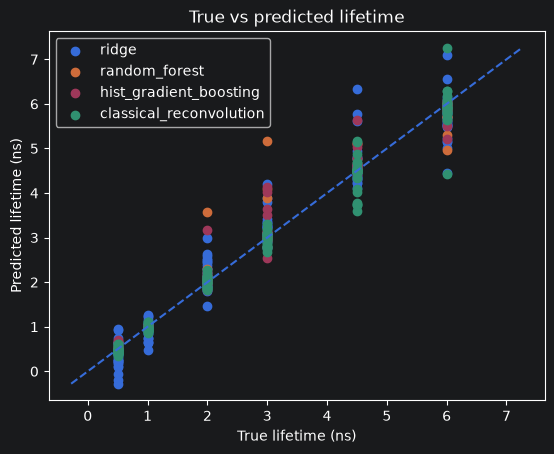

In [89]:
plot_true_vs_predicted(
    classical_and_ml_diagnostics
)

plt.show()

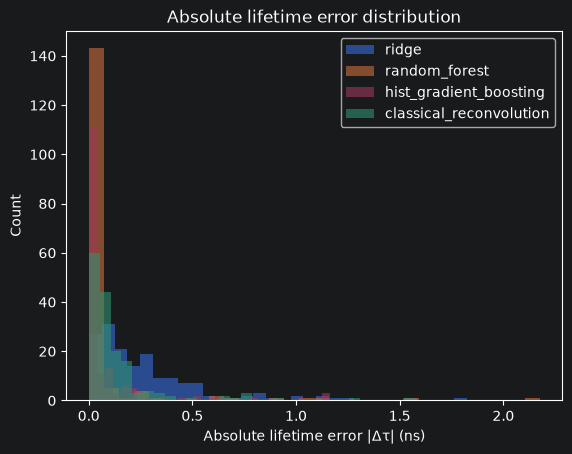

In [90]:
plot_error_histogram(
    classical_and_ml_diagnostics,
    absolute=True,
    bins=30,
)

plt.show()

In [91]:
random_forest_diagnostics = (
    engineered_ml_diagnostics.loc[
        engineered_ml_diagnostics[
            "estimator_name"
        ]
        == "random_forest"
    ]
    .copy()
)

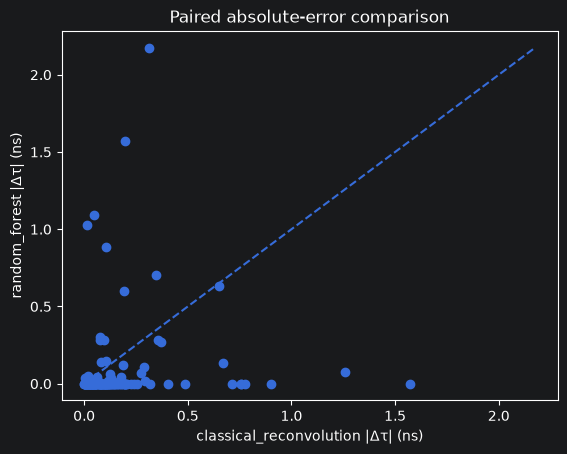

In [92]:
plot_paired_absolute_error_comparison(
    classical_diagnostics,
    random_forest_diagnostics,
)

plt.show()

In [93]:
paired_classical_rf = (
    classical_diagnostics.loc[
        classical_diagnostics[
            "valid_estimate"
        ],
        [
            "sample_id",
            "absolute_error_ns",
        ],
    ]
    .merge(
        random_forest_diagnostics[
            [
                "sample_id",
                "absolute_error_ns",
            ]
        ],
        on="sample_id",
        suffixes=(
            "_classical",
            "_random_forest",
        ),
    )
)

In [94]:
rf_better = (
    paired_classical_rf[
        "absolute_error_ns_random_forest"
    ]
    <
    paired_classical_rf[
        "absolute_error_ns_classical"
    ]
)

classical_better = (
    paired_classical_rf[
        "absolute_error_ns_classical"
    ]
    <
    paired_classical_rf[
        "absolute_error_ns_random_forest"
    ]
)

ties = (
    ~rf_better
    & ~classical_better
)

paired_win_summary = pd.DataFrame(
    [
        {
            "comparison": (
                "random_forest_better"
            ),
            "n_curves": int(
                rf_better.sum()
            ),
            "fraction_percent": (
                100.0
                * rf_better.mean()
            ),
        },
        {
            "comparison": (
                "classical_better"
            ),
            "n_curves": int(
                classical_better.sum()
            ),
            "fraction_percent": (
                100.0
                * classical_better.mean()
            ),
        },
        {
            "comparison": "tie",
            "n_curves": int(
                ties.sum()
            ),
            "fraction_percent": (
                100.0
                * ties.mean()
            ),
        },
    ]
)

paired_win_summary

,comparison,n_curves,fraction_percent
0,random_forest_better,146,90.123457
1,classical_better,16,9.876543
2,tie,0,0.000000


In [95]:
benchmark_split.metadata_test[
    "irf_fwhm_ns"
].value_counts().sort_index()

irf_fwhm_ns
0.15    53
0.30    65
0.60    44
Name: count, dtype: int64

### Classical IRF assumption

The classical fit uses a nominal IRF FWHM of 0.30 ns for every curve.

Therefore:

- 0.30 ns curves are width-matched to the assumed IRF;
- 0.15 ns curves are narrower than the assumed IRF;
- 0.60 ns curves are broader than the assumed IRF.

The aggregate comparison above intentionally combines these operating
conditions. Their separate effects are examined in the conditional
performance analysis in the following section.

### Classical-versus-ML observations

The classical reconvolution benchmark performs strongly across the complete
test set. All **162 histograms are fitted successfully**, giving a
**0% failure rate**, despite the use of a single nominal IRF width of
0.30 ns. The classical estimator achieves an MAE of approximately
**0.141 ns**, a median absolute error of approximately **0.079 ns**, and an
RMSE of approximately **0.256 ns**.

This places classical reconvolution clearly ahead of Ridge regression
($\mathrm{MAE}\approx0.283$ ns), but behind the two nonlinear
engineered-feature models. Histogram Gradient Boosting reaches an MAE of
approximately **0.091 ns**, while Random Forest gives the lowest aggregate
error at approximately **0.070 ns**.

The classical estimator also shows a small negative bias of approximately

$$
-0.043\ \mathrm{ns},
$$

indicating a slight overall tendency to underestimate lifetime. Its bias is
small compared with the lifetime range of the benchmark, but it is more
pronounced than the small positive biases of the three ML estimators.

Importantly, the absence of failed fits does not imply that every classical
fit is equally reliable. **22 of the 162 fits reach or approach a fitted
parameter boundary.** These fits are still classified as valid because the
optimizer converged to finite and physically allowed parameters, but the
boundary flag provides an additional diagnostic that can be examined when
studying difficult operating regimes.

The performance of classical reconvolution is particularly notable because
only **65 of the 162 test curves** have the same 0.30 ns IRF width as the
nominal IRF used by the fit. The remaining **97 curves** contain either a
narrower 0.15 ns IRF or a broader 0.60 ns IRF. Thus, the classical estimator
remains quantitatively competitive even when its assumed IRF width is not
exactly matched to the simulated measurement.

The paired comparison with Random Forest nevertheless shows a clear advantage
for the data-driven estimator on this benchmark. Random Forest produces the
smaller absolute lifetime error for **146 of 162 curves
($\approx90.1\%$)**, whereas classical reconvolution is more accurate for
**16 curves ($\approx9.9\%$))**. There are no exact ties.

The paired-error plot also shows why this result should not be reduced to a
simple statement that one method uniformly dominates the other. Most points
lie below the equal-error diagonal, often with Random Forest very close to
zero error while the classical error remains finite. However, several curves
show the opposite behaviour: classical reconvolution remains accurate while
Random Forest produces comparatively large errors, in some cases exceeding
1 ns. Classical fitting therefore provides important complementary behaviour
on a minority of measurements where the learned estimator makes an outlying
prediction.

This distinction is scientifically important. The classical estimator embeds
an explicit mono-exponential forward model and performs an independent
physical fit for every histogram. The ML estimators instead learn a mapping
from engineered histogram features to lifetime from the training
distribution. The latter can exploit systematic relationships among
lifetime, background, photon statistics, and IRF effects extremely
efficiently, but individual predictions are not constrained by an explicit
forward-model fit.

Overall, the results establish the following performance ordering for the
present in-distribution benchmark:

$$
\text{Random Forest}
>
\text{Histogram Gradient Boosting}
>
\text{classical reconvolution}
>
\text{Ridge},
$$

when ranked by aggregate MAE.

At the same time, classical reconvolution shows **100% fitting success,
good absolute accuracy, and complementary per-curve behaviour** despite
imperfect IRF-width calibration. The central research question is therefore
not simply whether ML has a lower aggregate error, but **under which physical
conditions the advantage shifts between classical and data-driven
estimation**.

The following section addresses this directly by separating performance
according to lifetime, photon-count, background, IRF-width, and
IRF-misalignment regimes.

## 6. Conditional performance across physical regimes

Aggregate metrics do not reveal under which measurement conditions an
estimator succeeds or fails.

The benchmark is therefore stratified according to five physically meaningful
variables:

- fluorescence lifetime,
- signal photon count,
- background level,
- IRF width,
- absolute IRF temporal misalignment.

For each regime and estimator, the analysis reports:

- number of samples,
- number of valid and failed estimates,
- failure rate,
- mean absolute error (MAE),
- median absolute error,
- signed bias,
- 90th-percentile absolute error,
- 95th-percentile absolute error.

The analysis includes the three engineered-feature ML estimators together
with classical reconvolution.

The central question is whether the aggregate advantage of the nonlinear ML
models is maintained uniformly across the physical parameter space, or
whether particular regimes favor classical fitting.

In [96]:
conditional_diagnostics = (
    add_benchmark_regimes(
        classical_and_ml_diagnostics,
        lifetime_edges=LIFETIME_EDGES,
        photon_count_edges=(
            PHOTON_COUNT_EDGES
        ),
        background_edges=(
            BACKGROUND_EDGES
        ),
        irf_width_edges=(
            IRF_WIDTH_EDGES
        ),
        irf_misalignment_edges=(
            IRF_MISALIGNMENT_EDGES
        ),
    )
)

In [97]:
conditional_diagnostics[
    [
        "true_lifetime_ns",
        "lifetime_regime",
        "signal_photon_count_target",
        "photon_count_regime",
        "background_per_bin",
        "background_regime",
        "irf_fwhm_ns",
        "irf_width_regime",
        "irf_shift_ns",
        "absolute_irf_shift_ns",
        "irf_misalignment_regime",
    ]
].drop_duplicates().sort_values(
    [
        "true_lifetime_ns",
        "signal_photon_count_target",
        "background_per_bin",
        "irf_fwhm_ns",
        "irf_shift_ns",
    ]
).head(20)

,true_lifetime_ns,lifetime_regime,signal_photon_count_target,photon_count_regime,background_per_bin,background_regime,irf_fwhm_ns,irf_width_regime,irf_shift_ns,absolute_irf_shift_ns,irf_misalignment_regime
153,0.5,short,1000.0,low,0.0,low,0.15,narrow,0.00,0.00,small
146,0.5,short,1000.0,low,0.0,low,0.30,medium,0.00,0.00,small
117,0.5,short,1000.0,low,0.0,low,0.60,broad,-0.20,0.20,large
35,0.5,short,1000.0,low,0.5,medium,0.30,medium,0.05,0.05,medium
129,0.5,short,1000.0,low,0.5,medium,0.60,broad,0.20,0.20,large
25,0.5,short,1000.0,low,2.0,high,0.15,narrow,-0.20,0.20,large
75,0.5,short,1000.0,low,2.0,high,0.15,narrow,-0.05,0.05,medium
74,0.5,short,1000.0,low,2.0,high,0.15,narrow,0.05,0.05,medium
24,0.5,short,1000.0,low,2.0,high,0.30,medium,0.20,0.20,large
67,0.5,short,10000.0,medium,0.0,low,0.15,narrow,0.20,0.20,large


In [98]:
for column in [
    "lifetime_regime",
    "photon_count_regime",
    "background_regime",
    "irf_width_regime",
    "irf_misalignment_regime",
]:
    print(
        column,
        conditional_diagnostics[
            column
        ].unique().tolist(),
    )

lifetime_regime ['short', 'long', 'medium']
photon_count_regime ['high', 'low', 'medium']
background_regime ['medium', 'high', 'low']
irf_width_regime ['medium', 'broad', 'narrow']
irf_misalignment_regime ['small', 'large', 'medium']


In [99]:
conditional_summaries = (
    summarize_standard_regimes(
        conditional_diagnostics
    )
)

In [100]:
conditional_summaries.keys()

dict_keys(['lifetime', 'photon_count', 'background', 'irf_width', 'irf_misalignment'])

In [101]:
lifetime_summary = (
    conditional_summaries[
        "lifetime"
    ]
)

lifetime_summary

,estimator_name,lifetime_regime,n_samples,n_valid_estimates,n_failed_estimates,failure_rate,mae_ns,median_absolute_error_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,short,52,52,0,0.0,0.219193,0.175200,-0.106357,0.424321,0.539324
1,ridge,long,57,57,0,0.0,0.354249,0.210952,-0.067082,0.904901,1.138996
2,ridge,medium,53,53,0,0.0,0.268105,0.199332,0.187894,0.569561,0.839458
3,random_forest,short,52,52,0,0.0,0.004423,0.000000,0.004423,0.000000,0.015750
4,random_forest,long,57,57,0,0.0,0.079737,0.000000,-0.021316,0.282000,0.606000
5,random_forest,medium,53,53,0,0.0,0.124434,0.000000,0.122170,0.136000,0.969000
6,hist_gradient_boosting,short,52,52,0,0.0,0.017067,0.004552,0.001843,0.044562,0.074771
7,hist_gradient_boosting,long,57,57,0,0.0,0.115091,0.032989,0.016067,0.322968,0.542402
8,hist_gradient_boosting,medium,53,53,0,0.0,0.136459,0.016596,0.081479,0.402753,0.792191
9,classical_reconvolution,short,52,52,0,0.0,0.063375,0.059078,-0.028978,0.111420,0.118655


In [102]:
lifetime_mae = (
    lifetime_summary
    .pivot(
        index="lifetime_regime",
        columns="estimator_name",
        values="mae_ns",
    )
)

lifetime_mae

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
lifetime_regime,,,,
long,0.240875,0.115091,0.079737,0.354249
medium,0.108896,0.136459,0.124434,0.268105
short,0.063375,0.017067,0.004423,0.219193


In [103]:
lifetime_p95 = (
    lifetime_summary
    .pivot(
        index="lifetime_regime",
        columns="estimator_name",
        values="p95_absolute_error_ns",
    )
)

lifetime_p95

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
lifetime_regime,,,,
long,0.800589,0.542402,0.60600,1.138996
medium,0.262758,0.792191,0.96900,0.839458
short,0.118655,0.074771,0.01575,0.539324


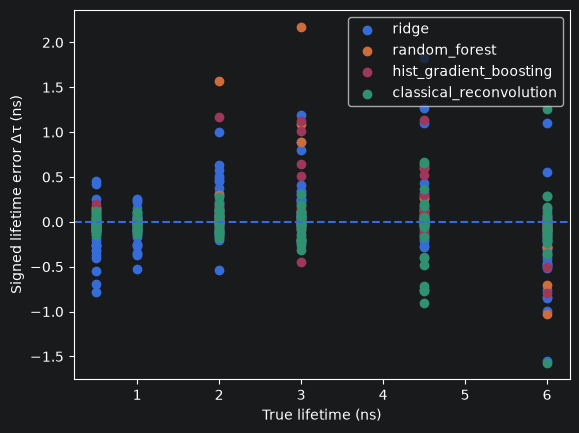

In [104]:
plot_error_vs_condition(
    conditional_diagnostics,
    condition_column=(
        "true_lifetime_ns"
    ),
)

plt.show()

In [105]:
photon_count_summary = (
    conditional_summaries[
        "photon_count"
    ]
)

photon_count_summary

,estimator_name,photon_count_regime,n_samples,n_valid_estimates,n_failed_estimates,failure_rate,mae_ns,median_absolute_error_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,high,52,52,0,0.0,0.148108,0.118088,-0.026528,0.309296,0.395827
1,ridge,low,46,46,0,0.0,0.464967,0.269071,0.165383,1.103816,1.253031
2,ridge,medium,64,64,0,0.0,0.261088,0.246324,-0.087876,0.458909,0.571426
3,random_forest,high,52,52,0,0.0,0.005481,0.000000,-0.005481,0.000000,0.000000
4,random_forest,low,46,46,0,0.0,0.209457,0.022500,0.151848,0.757500,1.077500
5,random_forest,medium,64,64,0,0.0,0.022656,0.000000,-0.018906,0.000000,0.111000
6,hist_gradient_boosting,high,52,52,0,0.0,0.016842,0.011047,-0.001793,0.035586,0.059928
7,hist_gradient_boosting,low,46,46,0,0.0,0.223979,0.092650,0.117467,0.565958,1.099679
8,hist_gradient_boosting,medium,64,64,0,0.0,0.054706,0.009196,0.000309,0.110238,0.212149
9,classical_reconvolution,high,52,52,0,0.0,0.188770,0.103108,-0.176746,0.467399,0.756134


In [106]:
photon_count_mae = (
    photon_count_summary
    .pivot(
        index="photon_count_regime",
        columns="estimator_name",
        values="mae_ns",
    )
)

photon_count_mae

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
photon_count_regime,,,,
high,0.188770,0.016842,0.005481,0.148108
low,0.149129,0.223979,0.209457,0.464967
medium,0.095639,0.054706,0.022656,0.261088


In [107]:
photon_count_p95 = (
    photon_count_summary
    .pivot(
        index="photon_count_regime",
        columns="estimator_name",
        values="p95_absolute_error_ns",
    )
)

photon_count_p95

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
photon_count_regime,,,,
high,0.756134,0.059928,0.0000,0.395827
low,0.582367,1.099679,1.0775,1.253031
medium,0.330894,0.212149,0.1110,0.571426


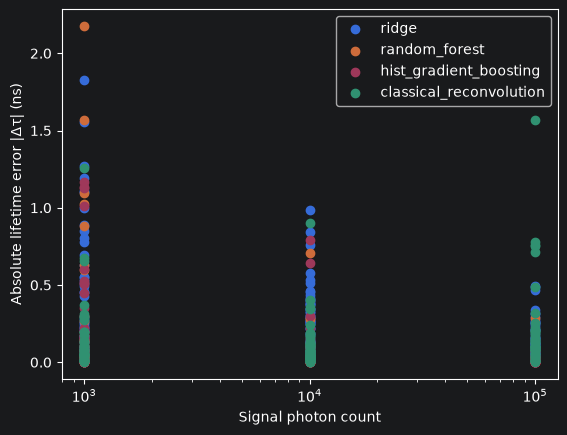

In [108]:
plot_error_vs_condition(
    conditional_diagnostics,
    condition_column=(
        "signal_photon_count_target"
    ),
    absolute=True,
    log_x=True,
)

plt.show()

In [109]:
background_summary = (
    conditional_summaries[
        "background"
    ]
)

background_summary

,estimator_name,background_regime,n_samples,n_valid_estimates,n_failed_estimates,failure_rate,mae_ns,median_absolute_error_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,medium,52,52,0,0.0,0.208169,0.157533,-0.037890,0.421514,0.672043
1,ridge,high,64,64,0,0.0,0.377514,0.279951,0.075224,0.865546,1.105132
2,ridge,low,46,46,0,0.0,0.235089,0.159665,-0.048695,0.470681,0.510819
3,random_forest,medium,52,52,0,0.0,0.048365,0.000000,0.034712,0.130500,0.291750
4,random_forest,high,64,64,0,0.0,0.104922,0.000000,0.087109,0.130500,0.577500
5,random_forest,low,46,46,0,0.0,0.046522,0.000000,-0.041087,0.032500,0.223750
6,hist_gradient_boosting,medium,52,52,0,0.0,0.072482,0.012291,0.011308,0.156490,0.211330
7,hist_gradient_boosting,high,64,64,0,0.0,0.134202,0.020684,0.068593,0.463726,0.766597
8,hist_gradient_boosting,low,46,46,0,0.0,0.050477,0.016075,0.007654,0.103719,0.146777
9,classical_reconvolution,medium,52,52,0,0.0,0.113568,0.090444,-0.042909,0.199106,0.303090


In [110]:
background_mae = (
    background_summary
    .pivot(
        index="background_regime",
        columns="estimator_name",
        values="mae_ns",
    )
)

background_mae

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
background_regime,,,,
high,0.171011,0.134202,0.104922,0.377514
low,0.129274,0.050477,0.046522,0.235089
medium,0.113568,0.072482,0.048365,0.208169


In [111]:
background_p95 = (
    background_summary
    .pivot(
        index="background_regime",
        columns="estimator_name",
        values="p95_absolute_error_ns",
    )
)

background_p95

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
background_regime,,,,
high,0.668988,0.766597,0.57750,1.105132
low,0.635936,0.146777,0.22375,0.510819
medium,0.303090,0.211330,0.29175,0.672043


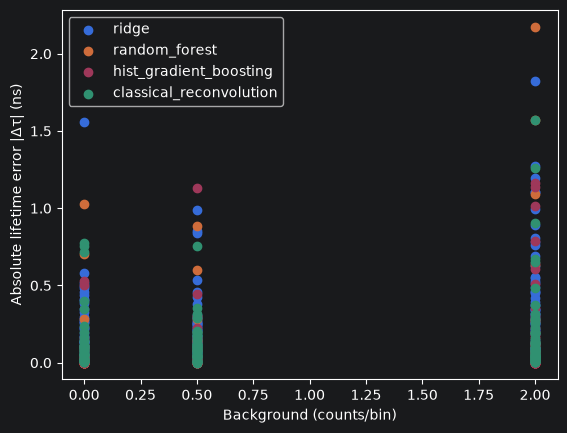

In [112]:
plot_error_vs_condition(
    conditional_diagnostics,
    condition_column=(
        "background_per_bin"
    ),
    absolute=True,
)

plt.show()

In [113]:
irf_width_summary = (
    conditional_summaries[
        "irf_width"
    ]
)

irf_width_summary

,estimator_name,irf_width_regime,n_samples,n_valid_estimates,n_failed_estimates,failure_rate,mae_ns,median_absolute_error_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,medium,65,65,0,0.0,0.274592,0.159613,-0.026802,0.734309,0.883163
1,ridge,broad,44,44,0,0.0,0.309246,0.248793,0.093995,0.559904,0.954046
2,ridge,narrow,53,53,0,0.0,0.270650,0.185194,-0.033765,0.546689,0.726970
3,random_forest,medium,65,65,0,0.0,0.063385,0.000000,0.026154,0.056000,0.532000
4,random_forest,broad,44,44,0,0.0,0.093977,0.000000,0.034205,0.277000,0.552750
5,random_forest,narrow,53,53,0,0.0,0.058774,0.000000,0.043113,0.035000,0.195000
6,hist_gradient_boosting,medium,65,65,0,0.0,0.092595,0.008667,0.037904,0.213121,0.509185
7,hist_gradient_boosting,broad,44,44,0,0.0,0.119823,0.027697,0.033419,0.373275,0.638678
8,hist_gradient_boosting,narrow,53,53,0,0.0,0.063945,0.015721,0.026336,0.149047,0.231189
9,classical_reconvolution,medium,65,65,0,0.0,0.112108,0.053596,-0.023602,0.216712,0.385100


In [114]:
irf_width_mae = (
    irf_width_summary
    .pivot(
        index="irf_width_regime",
        columns="estimator_name",
        values="mae_ns",
    )
)

irf_width_mae

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
irf_width_regime,,,,
broad,0.125378,0.119823,0.093977,0.309246
medium,0.112108,0.092595,0.063385,0.274592
narrow,0.188551,0.063945,0.058774,0.270650


In [115]:
irf_width_p95 = (
    irf_width_summary
    .pivot(
        index="irf_width_regime",
        columns="estimator_name",
        values="p95_absolute_error_ns",
    )
)

irf_width_p95

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
irf_width_regime,,,,
broad,0.336201,0.638678,0.55275,0.954046
medium,0.385100,0.509185,0.53200,0.883163
narrow,0.765097,0.231189,0.19500,0.726970


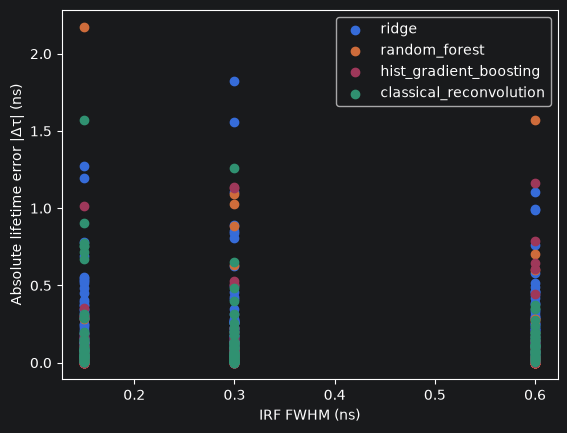

In [116]:
plot_error_vs_condition(
    conditional_diagnostics,
    condition_column="irf_fwhm_ns",
    absolute=True,
)

plt.show()

In [117]:
irf_misalignment_summary = (
    conditional_summaries[
        "irf_misalignment"
    ]
)

irf_misalignment_summary

,estimator_name,irf_misalignment_regime,n_samples,n_valid_estimates,n_failed_estimates,failure_rate,mae_ns,median_absolute_error_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,small,23,23,0,0.0,0.172766,0.133308,0.031724,0.338573,0.445334
1,ridge,large,75,75,0,0.0,0.346152,0.253834,0.025061,0.794034,1.057095
2,ridge,medium,64,64,0,0.0,0.247887,0.167058,-0.031330,0.532462,0.819363
3,random_forest,small,23,23,0,0.0,0.003261,0.000000,0.003261,0.016000,0.020000
4,random_forest,large,75,75,0,0.0,0.139067,0.000000,0.064267,0.474000,0.927000
5,random_forest,medium,64,64,0,0.0,0.013516,0.000000,0.009297,0.023500,0.068500
6,hist_gradient_boosting,small,23,23,0,0.0,0.045189,0.004747,-0.020861,0.096414,0.209519
7,hist_gradient_boosting,large,75,75,0,0.0,0.143883,0.025990,0.060039,0.507713,0.855771
8,hist_gradient_boosting,medium,64,64,0,0.0,0.044522,0.011047,0.020421,0.106314,0.168843
9,classical_reconvolution,small,23,23,0,0.0,0.071938,0.046061,-0.021079,0.121744,0.193215


In [118]:
irf_misalignment_mae = (
    irf_misalignment_summary
    .pivot(
        index="irf_misalignment_regime",
        columns="estimator_name",
        values="mae_ns",
    )
)

irf_misalignment_mae

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
irf_misalignment_regime,,,,
large,0.131054,0.143883,0.139067,0.346152
medium,0.176770,0.044522,0.013516,0.247887
small,0.071938,0.045189,0.003261,0.172766


In [119]:
irf_misalignment_p95 = (
    irf_misalignment_summary
    .pivot(
        index="irf_misalignment_regime",
        columns="estimator_name",
        values="p95_absolute_error_ns",
    )
)

irf_misalignment_p95

estimator_name,classical_reconvolution,hist_gradient_boosting,random_forest,ridge
irf_misalignment_regime,,,,
large,0.477270,0.855771,0.9270,1.057095
medium,0.766067,0.168843,0.0685,0.819363
small,0.193215,0.209519,0.0200,0.445334


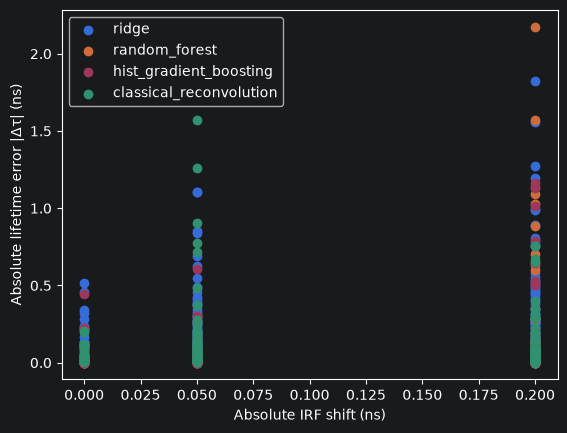

In [120]:
plot_error_vs_condition(
    conditional_diagnostics,
    condition_column=(
        "absolute_irf_shift_ns"
    ),
    absolute=True,
)

plt.show()

In [121]:
rf_classical_lifetime = (
    lifetime_mae[
        [
            "random_forest",
            "classical_reconvolution",
        ]
    ]
    .copy()
)

rf_classical_lifetime[
    "classical_to_rf_mae_ratio"
] = (
    rf_classical_lifetime[
        "classical_reconvolution"
    ]
    / rf_classical_lifetime[
        "random_forest"
    ]
)

rf_classical_lifetime

estimator_name,random_forest,classical_reconvolution,classical_to_rf_mae_ratio
lifetime_regime,,,
long,0.079737,0.240875,3.020880
medium,0.124434,0.108896,0.875128
short,0.004423,0.063375,14.328246


In [122]:
rf_classical_photon_count = (
    photon_count_mae[
        [
            "random_forest",
            "classical_reconvolution",
        ]
    ]
    .copy()
)

rf_classical_photon_count[
    "classical_to_rf_mae_ratio"
] = (
    rf_classical_photon_count[
        "classical_reconvolution"
    ]
    / rf_classical_photon_count[
        "random_forest"
    ]
)

rf_classical_photon_count

estimator_name,random_forest,classical_reconvolution,classical_to_rf_mae_ratio
photon_count_regime,,,
high,0.005481,0.188770,34.442268
low,0.209457,0.149129,0.711983
medium,0.022656,0.095639,4.221286


In [123]:
rf_classical_background = (
    background_mae[
        [
            "random_forest",
            "classical_reconvolution",
        ]
    ]
    .copy()
)

rf_classical_background[
    "classical_to_rf_mae_ratio"
] = (
    rf_classical_background[
        "classical_reconvolution"
    ]
    / rf_classical_background[
        "random_forest"
    ]
)

rf_classical_background

estimator_name,random_forest,classical_reconvolution,classical_to_rf_mae_ratio
background_regime,,,
high,0.104922,0.171011,1.629885
low,0.046522,0.129274,2.778797
medium,0.048365,0.113568,2.348136


In [124]:
rf_classical_irf_width = (
    irf_width_mae[
        [
            "random_forest",
            "classical_reconvolution",
        ]
    ]
    .copy()
)

rf_classical_irf_width[
    "classical_to_rf_mae_ratio"
] = (
    rf_classical_irf_width[
        "classical_reconvolution"
    ]
    / rf_classical_irf_width[
        "random_forest"
    ]
)

rf_classical_irf_width

estimator_name,random_forest,classical_reconvolution,classical_to_rf_mae_ratio
irf_width_regime,,,
broad,0.093977,0.125378,1.334135
medium,0.063385,0.112108,1.768698
narrow,0.058774,0.188551,3.208085


In [125]:
rf_classical_irf_misalignment = (
    irf_misalignment_mae[
        [
            "random_forest",
            "classical_reconvolution",
        ]
    ]
    .copy()
)

rf_classical_irf_misalignment[
    "classical_to_rf_mae_ratio"
] = (
    rf_classical_irf_misalignment[
        "classical_reconvolution"
    ]
    / rf_classical_irf_misalignment[
        "random_forest"
    ]
)

rf_classical_irf_misalignment

estimator_name,random_forest,classical_reconvolution,classical_to_rf_mae_ratio
irf_misalignment_regime,,,
large,0.139067,0.131054,0.942383
medium,0.013516,0.176770,13.078900
small,0.003261,0.071938,22.060896


In [126]:
classical_conditional = (
    conditional_diagnostics.loc[
        conditional_diagnostics[
            "estimator_name"
        ]
        == "classical_reconvolution"
    ]
    .copy()
)

In [127]:
classical_boundary_by_irf_width = (
    classical_conditional
    .groupby(
        "irf_width_regime",
        observed=True,
    )[
        "boundary_hit"
    ]
    .agg(
        [
            "sum",
            "count",
            "mean",
        ]
    )
)

classical_boundary_by_irf_width[
    "boundary_hit_percent"
] = (
    100.0
    * classical_boundary_by_irf_width[
        "mean"
    ]
)

classical_boundary_by_irf_width

,sum,count,mean,boundary_hit_percent
irf_width_regime,,,,
narrow,11,53,0.207547,20.754717
medium,10,65,0.153846,15.384615
broad,1,44,0.022727,2.272727


In [128]:
classical_boundary_by_photon_count = (
    classical_conditional
    .groupby(
        "photon_count_regime",
        observed=True,
    )[
        "boundary_hit"
    ]
    .agg(
        [
            "sum",
            "count",
            "mean",
        ]
    )
)

classical_boundary_by_photon_count[
    "boundary_hit_percent"
] = (
    100.0
    * classical_boundary_by_photon_count[
        "mean"
    ]
)

classical_boundary_by_photon_count

,sum,count,mean,boundary_hit_percent
photon_count_regime,,,,
low,9,46,0.195652,19.565217
medium,9,64,0.140625,14.0625
high,4,52,0.076923,7.692308


In [129]:
classical_boundary_by_background = (
    classical_conditional
    .groupby(
        "background_regime",
        observed=True,
    )[
        "boundary_hit"
    ]
    .agg(
        [
            "sum",
            "count",
            "mean",
        ]
    )
)

classical_boundary_by_background[
    "boundary_hit_percent"
] = (
    100.0
    * classical_boundary_by_background[
        "mean"
    ]
)

classical_boundary_by_background

,sum,count,mean,boundary_hit_percent
background_regime,,,,
low,22,46,0.478261,47.826087
medium,0,52,0.0,0.0
high,0,64,0.0,0.0


In [130]:
for (
    condition_name,
    summary,
) in conditional_summaries.items():

    maximum_failure_rate = (
        summary[
            "failure_rate"
        ].max()
    )

    print(
        condition_name,
        maximum_failure_rate,
    )

lifetime 0.0
photon_count 0.0
background 0.0
irf_width 0.0
irf_misalignment 0.0


### Conditional-performance observations

The conditional analysis shows that the aggregate ranking of the estimators
does **not** hold uniformly across the physical parameter space. Although
Random Forest has the lowest overall MAE, classical reconvolution becomes
competitive or superior in several specific regimes.

All estimators produce valid estimates in every regime. In particular,
classical reconvolution retains a **0% failure rate throughout the complete
conditional analysis**, so changes in its performance reflect changes in
accuracy rather than optimizer failure.

#### Lifetime dependence

For **short lifetimes** (0.5–1.0 ns), Random Forest is exceptionally accurate,
with an MAE of approximately **0.004 ns**, compared with **0.017 ns** for
Histogram Gradient Boosting and **0.063 ns** for classical reconvolution.

For **long lifetimes** (4.5–6.0 ns), Random Forest again performs best
$(\mathrm{MAE}\approx0.080$ ns), followed by Histogram Gradient Boosting
$(\approx0.115$ ns), while classical reconvolution reaches approximately
**0.241 ns**.

The ordering changes in the **medium-lifetime regime** (2–3 ns). Here,
classical reconvolution achieves an MAE of approximately **0.109 ns**, slightly
better than Random Forest at **0.124 ns** and Histogram Gradient Boosting at
**0.136 ns**. Classical fitting is also substantially more stable in the
error tail in this regime: its 95th-percentile absolute error is approximately
**0.263 ns**, compared with **0.969 ns** for Random Forest and **0.792 ns** for
Histogram Gradient Boosting.

Thus, the nonlinear ML models provide the best typical accuracy over much of
the lifetime range, but classical reconvolution can provide more stable
behaviour in specific lifetime regimes.

#### Photon-count dependence

Photon statistics produce one of the clearest changes in relative estimator
performance.

At **1,000 photons**, classical reconvolution has the lowest MAE among the
three strongest estimators:

$$
\mathrm{MAE}_{\mathrm{classical}}\approx0.149\ \mathrm{ns},
$$

compared with approximately **0.209 ns** for Random Forest and **0.224 ns**
for Histogram Gradient Boosting.

The situation reverses strongly as photon statistics improve. At
**10,000 photons**, Random Forest reaches approximately **0.023 ns**, and at
**100,000 photons** its MAE falls to only approximately **0.005 ns**.
Histogram Gradient Boosting shows a similar trend.

Classical reconvolution does not exhibit the same monotonic improvement:
its MAEs are approximately **0.149, 0.096, and 0.189 ns** in the low,
medium, and high photon-count regimes, respectively. This behaviour is
consistent with the idea that, once photon-counting noise becomes small,
systematic effects such as imperfect IRF modelling can dominate the remaining
classical fitting error.

Consequently, the aggregate ML advantage is driven especially strongly by
the medium- and high-photon regimes, whereas classical fitting is more
competitive under photon-starved conditions.

#### Background dependence

Random Forest gives the lowest MAE at **all three background levels**:

$$
0.047,\quad 0.048,\quad 0.105\ \mathrm{ns}
$$

for low, medium, and high background, respectively.

All estimators nevertheless degrade as the highest background level is
reached. Classical reconvolution increases to approximately **0.171 ns** MAE,
while Histogram Gradient Boosting reaches approximately **0.134 ns** and
Random Forest approximately **0.105 ns**.

Thus, the engineered-feature nonlinear models compensate for background
contamination more effectively in terms of typical error, although the
high-background regime remains more difficult for all methods.

#### IRF-width dependence

The IRF-width analysis is particularly important because classical
reconvolution uses a fixed nominal FWHM of 0.30 ns.

Random Forest has the lowest MAE in all three width regimes:

$$
0.059\ \mathrm{ns}\quad\text{(narrow)},
\qquad
0.063\ \mathrm{ns}\quad\text{(matched)},
\qquad
0.094\ \mathrm{ns}\quad\text{(broad)}.
$$

Classical reconvolution performs best when the actual IRF width is close to
the nominal assumption, with an MAE of approximately **0.112 ns** in the
0.30-ns regime. Its MAE increases to approximately **0.189 ns** for the
narrow 0.15-ns IRF. Interestingly, the broad 0.60-ns regime remains relatively
well behaved at approximately **0.125 ns**, showing that the effect of
IRF-width mismatch is not symmetric.

The tail statistics add further nuance. For broad IRFs, classical
reconvolution has a 95th-percentile error of approximately **0.336 ns**,
smaller than the approximately **0.553 ns** obtained by Random Forest.
Therefore, although Random Forest gives the lower average error, classical
fitting can retain better protection against occasional large errors in some
IRF-width regimes.

#### IRF temporal misalignment

Temporal misalignment produces perhaps the clearest example of complementary
behaviour.

For **small** and **medium** shifts, Random Forest is substantially more
accurate, with MAEs of approximately **0.003 ns** and **0.014 ns**,
respectively.

For the **large-misalignment regime** $(|\Delta t|=0.20$ ns), however,
classical reconvolution becomes marginally the best estimator:

$$
\mathrm{MAE}_{\mathrm{classical}}
\approx0.131\ \mathrm{ns},
$$

compared with approximately **0.139 ns** for Random Forest and **0.144 ns**
for Histogram Gradient Boosting.

The difference is even clearer in the error tails. Classical reconvolution
has a 95th-percentile error of approximately **0.477 ns**, whereas Random
Forest and Histogram Gradient Boosting reach approximately **0.927 ns** and
**0.856 ns**, respectively.

This result is physically consistent with the classical model explicitly
fitting the temporal IRF shift as a free parameter. Large temporal
misalignment is therefore a nuisance variable that the physical model is
specifically designed to accommodate.

#### Classical boundary diagnostics

The classical optimizer reaches or approaches a fitted parameter boundary in
22 curves, but these boundary hits are strongly structured. All **22 occur
in the zero-background regime**, corresponding to approximately **48%** of
those curves, whereas no boundary hits occur at 0.5 or 2 counts/bin.

This is important for interpretation: these boundary flags do not indicate
22 arbitrary numerical instabilities. They are largely consistent with the
fitted background reaching its physically allowed lower limit when the true
simulated background is itself zero.

Boundary hits are also more common at low photon count and for narrow IRFs,
but these trends overlap with the same zero-background cases and should not
be interpreted independently as optimizer failures.

#### Overall conditional picture

The main conclusion is therefore more nuanced than the aggregate ranking.

Random Forest provides the **best overall and most frequently best
per-curve accuracy**, particularly at moderate-to-high photon counts and
across the background and IRF-width regimes. However, classical
reconvolution becomes competitive or superior in several physically
important situations:

- the **low-photon** regime,
- the **medium-lifetime** regime,
- and especially the **large IRF-misalignment** regime.

Classical fitting also sometimes exhibits substantially smaller
95th-percentile errors even when its mean error is higher.

The results therefore support the central idea that data-driven and
physically explicit estimators are **complementary rather than universally
ordered**. Machine learning can exploit recurring structure in the benchmark
distribution to obtain extremely high accuracy, while the explicit physical
model can retain robustness when a nuisance parameter is directly represented
in the fitting model or when the learned estimator encounters a difficult
measurement.

The next section tests a stronger form of robustness by deliberately
violating the shared mono-exponential model assumption through controlled
bi-exponential contamination.

## 7. Controlled bi-exponential model mismatch

The previous sections evaluated estimators within the mono-exponential
simulation family used to construct the training data and classical forward
model.

A more demanding robustness test is now introduced by deliberately violating
this shared model assumption.

For every original test condition, a matched bi-exponential histogram is
generated with

$$
\tau_2 = 2\tau_1
$$

and a secondary component contributing

$$
f_2 = 0.10
$$

of the expected detected signal photons.

The original primary lifetime $\tau_1$ remains the regression target.

Photon count, background, IRF width, and IRF temporal shift are preserved
sample-by-sample. The only systematic change is therefore the additional
secondary decay component.

The machine-learning models remain trained exclusively on mono-exponential
training data. Likewise, classical reconvolution continues to fit a
mono-exponential forward model.

This experiment therefore compares two different forms of model mismatch:

- **ML distribution shift:** the test histogram shape no longer follows the
  training distribution;
- **classical forward-model mismatch:** the physical fit uses an incorrect
  mono-exponential decay model.

No estimator is adapted or retrained for the mismatch condition.

In [131]:
SECONDARY_FRACTION = 0.10
SECONDARY_LIFETIME_FACTOR = 2.0
MISMATCH_RANDOM_SEED = 42

`SECONDARY_FRACTION = 0.10` refers to the fraction of expected **detected
signal photons** contributed by the secondary component within the
measurement window.

It is therefore not simply a raw exponential-amplitude ratio.

In [132]:
mismatch_dataset = (
    generate_matched_biexponential_mismatch_dataset(
        time=time,
        reference_split=benchmark_split,
        feature_config=feature_config,
        irf_centre_ns=irf_centre_ns,
        secondary_fraction=SECONDARY_FRACTION,
        secondary_lifetime_factor=(
            SECONDARY_LIFETIME_FACTOR
        ),
        random_seed=MISMATCH_RANDOM_SEED,
    )
)

In [133]:
print(
    "Original test histograms:",
    benchmark_split.X_histograms_test.shape,
)

print(
    "Mismatch histograms:",
    mismatch_dataset.X_histograms.shape,
)

print(
    "Mismatch features:",
    mismatch_dataset.X_features.shape,
)

print(
    "Mismatch targets:",
    mismatch_dataset.y.shape,
)

Original test histograms: (162, 400)
Mismatch histograms: (162, 400)
Mismatch features: (162, 15)
Mismatch targets: (162,)


In [134]:
np.testing.assert_allclose(
    mismatch_dataset.y,
    benchmark_split.y_test,
)

In [135]:
matched_metadata_columns = [
    "signal_photon_count_target",
    "background_per_bin",
    "irf_fwhm_ns",
    "irf_shift_ns",
]

for column in matched_metadata_columns:
    np.testing.assert_allclose(
        mismatch_dataset.metadata[
            column
        ].to_numpy(
            dtype=np.float64
        ),
        benchmark_split.metadata_test[
            column
        ].to_numpy(
            dtype=np.float64
        ),
    )

print(
    "All nuisance conditions matched."
)

All nuisance conditions matched.


In [136]:
mismatch_dataset.metadata[
    [
        "sample_id",
        "primary_lifetime_ns",
        "secondary_lifetime_ns",
        "secondary_fraction",
        "secondary_lifetime_factor",
        "signal_photon_count_target",
        "background_per_bin",
        "irf_fwhm_ns",
        "irf_shift_ns",
        "mismatch_type",
    ]
].head(10)

,sample_id,primary_lifetime_ns,secondary_lifetime_ns,secondary_fraction,secondary_lifetime_factor,signal_photon_count_target,background_per_bin,irf_fwhm_ns,irf_shift_ns,mismatch_type
0,247.0,1.0,2.0,0.1,2.0,100000.0,0.5,0.30,0.00,biexponential_contamination
1,670.0,4.5,9.0,0.1,2.0,100000.0,2.0,0.60,-0.20,biexponential_contamination
2,227.0,1.0,2.0,0.1,2.0,100000.0,0.0,0.15,0.00,biexponential_contamination
3,290.0,2.0,4.0,0.1,2.0,1000.0,0.5,0.30,-0.20,biexponential_contamination
4,538.0,3.0,6.0,0.1,2.0,100000.0,2.0,0.60,0.05,biexponential_contamination
5,796.0,6.0,12.0,0.1,2.0,100000.0,2.0,0.15,-0.05,biexponential_contamination
6,198.0,1.0,2.0,0.1,2.0,10000.0,0.5,0.15,0.05,biexponential_contamination
7,596.0,4.5,9.0,0.1,2.0,10000.0,0.0,0.60,-0.05,biexponential_contamination
8,319.0,2.0,4.0,0.1,2.0,10000.0,0.0,0.15,0.20,biexponential_contamination
9,569.0,4.5,9.0,0.1,2.0,1000.0,0.5,0.60,0.20,biexponential_contamination


In [137]:
np.testing.assert_allclose(
    mismatch_dataset.metadata[
        "secondary_lifetime_ns"
    ],
    (
        SECONDARY_LIFETIME_FACTOR
        * mismatch_dataset.metadata[
            "primary_lifetime_ns"
        ]
    ),
)

In [138]:
np.testing.assert_allclose(
    mismatch_dataset.metadata[
        "secondary_fraction"
    ],
    SECONDARY_FRACTION,
)

In [139]:
ml_mismatch_results = (
    evaluate_ml_mismatch_benchmark(
        reference_split=benchmark_split,
        mismatch_dataset=mismatch_dataset,
    )
)

In [140]:
ml_mismatch_results.keys()

dict_keys(['ridge', 'random_forest', 'hist_gradient_boosting'])

In [141]:
classical_mismatch_result = (
    evaluate_classical_mismatch_benchmark(
        time=time,
        reference_split=benchmark_split,
        mismatch_dataset=mismatch_dataset,
        irf=nominal_irf,
        temporal_shift_bounds=(
            TEMPORAL_SHIFT_BOUNDS
        ),
        objective=CLASSICAL_OBJECTIVE,
    )
)

In [142]:
mismatch_summary = (
    summarize_mismatch_benchmark(
        y_true=benchmark_split.y_test,
        ml_results=ml_mismatch_results,
        classical_result=(
            classical_mismatch_result
        ),
    )
)

In [143]:
mismatch_summary

,estimator,in_distribution_mae_ns,mismatch_mae_ns,mae_change_ns,mae_ratio,in_distribution_bias_ns,mismatch_bias_ns,in_distribution_failure_rate,mismatch_failure_rate
0,ridge,0.282715,0.306709,0.023994,1.084872,0.003729,0.154616,0.0,0.0
1,random_forest,0.070185,0.085710,0.015525,1.221196,0.033889,0.072685,0.0,0.0
2,hist_gradient_boosting,0.090617,0.141676,0.051059,1.563456,0.032901,0.072150,0.0,0.0
3,reconvolution,0.140721,0.215231,0.074510,1.529486,-0.043069,0.122166,0.0,0.0


In [144]:
mismatch_summary_sorted = (
    mismatch_summary
    .sort_values(
        "mismatch_mae_ns"
    )
    .reset_index(
        drop=True
    )
)

mismatch_summary_sorted

,estimator,in_distribution_mae_ns,mismatch_mae_ns,mae_change_ns,mae_ratio,in_distribution_bias_ns,mismatch_bias_ns,in_distribution_failure_rate,mismatch_failure_rate
0,random_forest,0.070185,0.085710,0.015525,1.221196,0.033889,0.072685,0.0,0.0
1,hist_gradient_boosting,0.090617,0.141676,0.051059,1.563456,0.032901,0.072150,0.0,0.0
2,reconvolution,0.140721,0.215231,0.074510,1.529486,-0.043069,0.122166,0.0,0.0
3,ridge,0.282715,0.306709,0.023994,1.084872,0.003729,0.154616,0.0,0.0


In [145]:
mismatch_degradation = (
    mismatch_summary.copy()
)

mismatch_degradation[
    "mae_increase_percent"
] = (
    100.0
    * (
        mismatch_degradation[
            "mismatch_mae_ns"
        ]
        - mismatch_degradation[
            "in_distribution_mae_ns"
        ]
    )
    / mismatch_degradation[
        "in_distribution_mae_ns"
    ]
)

mismatch_degradation[
    [
        "estimator",
        "in_distribution_mae_ns",
        "mismatch_mae_ns",
        "mae_increase_percent",
        "in_distribution_bias_ns",
        "mismatch_bias_ns",
        "mismatch_failure_rate",
    ]
].sort_values(
    "mismatch_mae_ns"
)

,estimator,in_distribution_mae_ns,mismatch_mae_ns,mae_increase_percent,in_distribution_bias_ns,mismatch_bias_ns,mismatch_failure_rate
1,random_forest,0.070185,0.085710,22.119613,0.033889,0.072685,0.0
2,hist_gradient_boosting,0.090617,0.141676,56.345555,0.032901,0.072150,0.0
3,reconvolution,0.140721,0.215231,52.948618,-0.043069,0.122166,0.0
0,ridge,0.282715,0.306709,8.487152,0.003729,0.154616,0.0


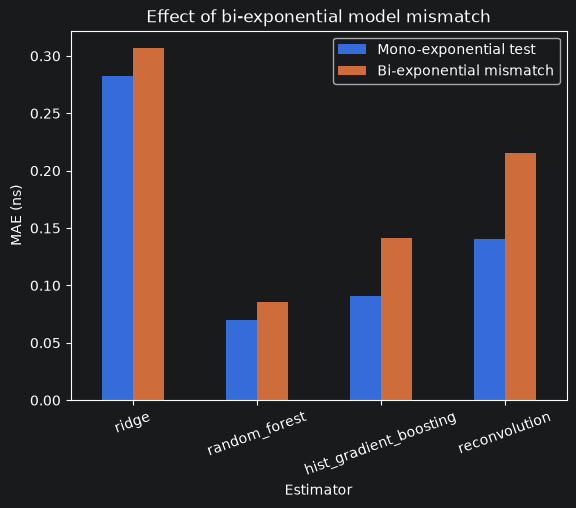

In [146]:
mismatch_mae_plot = (
    mismatch_summary[
        [
            "estimator",
            "in_distribution_mae_ns",
            "mismatch_mae_ns",
        ]
    ]
    .set_index(
        "estimator"
    )
)

mismatch_mae_plot.plot(
    kind="bar",
)

plt.ylabel(
    "MAE (ns)"
)

plt.xlabel(
    "Estimator"
)

plt.title(
    "Effect of bi-exponential model mismatch"
)

plt.xticks(
    rotation=20,
)

plt.legend(
    [
        "Mono-exponential test",
        "Bi-exponential mismatch",
    ]
)

plt.show()

In [147]:
bias_comparison = (
    mismatch_summary[
        [
            "estimator",
            "in_distribution_bias_ns",
            "mismatch_bias_ns",
        ]
    ]
)

bias_comparison

,estimator,in_distribution_bias_ns,mismatch_bias_ns
0,ridge,0.003729,0.154616
1,random_forest,0.033889,0.072685
2,hist_gradient_boosting,0.032901,0.072150
3,reconvolution,-0.043069,0.122166


In [148]:
ml_mismatch_diagnostics = pd.concat(
    [
        build_prediction_diagnostics(
            estimator_name=(
                estimator_name
                + "_biexponential"
            ),
            y_true=mismatch_dataset.y,
            y_pred=(
                result.mismatch.y_pred
            ),
            metadata=(
                mismatch_dataset.metadata
            ),
        )
        for (
            estimator_name,
            result,
        )
        in ml_mismatch_results.items()
    ],
    ignore_index=True,
)

In [149]:
classical_mismatch_diagnostics = (
    build_classical_prediction_diagnostics(
        classical_mismatch_result.mismatch,
        estimator_name=(
            "classical_reconvolution_biexponential"
        ),
    )
)

In [150]:
all_mismatch_diagnostics = pd.concat(
    [
        ml_mismatch_diagnostics,
        classical_mismatch_diagnostics,
    ],
    ignore_index=True,
)

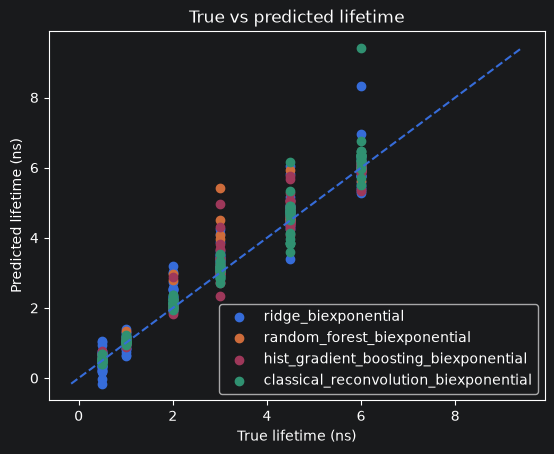

In [151]:
plot_true_vs_predicted(
    all_mismatch_diagnostics
)

plt.show()

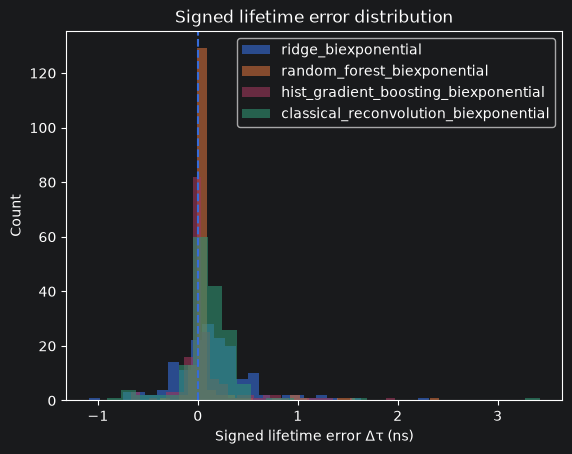

In [152]:
plot_error_histogram(
    all_mismatch_diagnostics,
    bins=30,
)

plt.show()

In [153]:
rf_in_distribution_diagnostics = (
    build_prediction_diagnostics(
        estimator_name=(
            "random_forest_mono"
        ),
        y_true=benchmark_split.y_test,
        y_pred=(
            ml_mismatch_results[
                "random_forest"
            ]
            .in_distribution
            .y_pred
        ),
        metadata=(
            benchmark_split.metadata_test
        ),
    )
)

In [154]:
rf_biexponential_diagnostics = (
    build_prediction_diagnostics(
        estimator_name=(
            "random_forest_biexponential"
        ),
        y_true=mismatch_dataset.y,
        y_pred=(
            ml_mismatch_results[
                "random_forest"
            ]
            .mismatch
            .y_pred
        ),
        metadata=(
            mismatch_dataset.metadata
        ),
    )
)

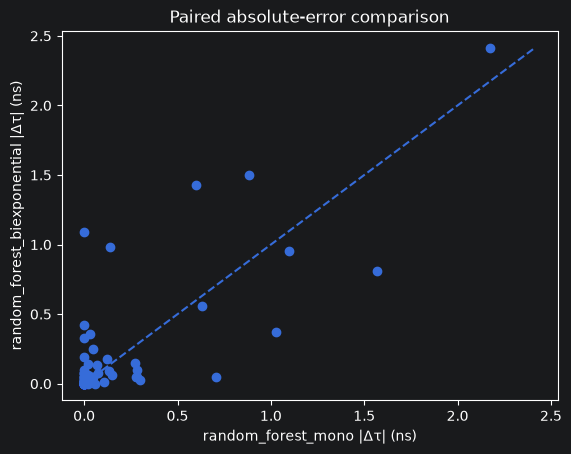

In [155]:
plot_paired_absolute_error_comparison(
    rf_in_distribution_diagnostics,
    rf_biexponential_diagnostics,
)

plt.show()

In [156]:
classical_in_distribution_diagnostics = (
    build_classical_prediction_diagnostics(
        classical_mismatch_result
        .in_distribution,
        estimator_name=(
            "classical_mono"
        ),
    )
)

In [157]:
classical_biexponential_diagnostics = (
    build_classical_prediction_diagnostics(
        classical_mismatch_result
        .mismatch,
        estimator_name=(
            "classical_biexponential"
        ),
    )
)

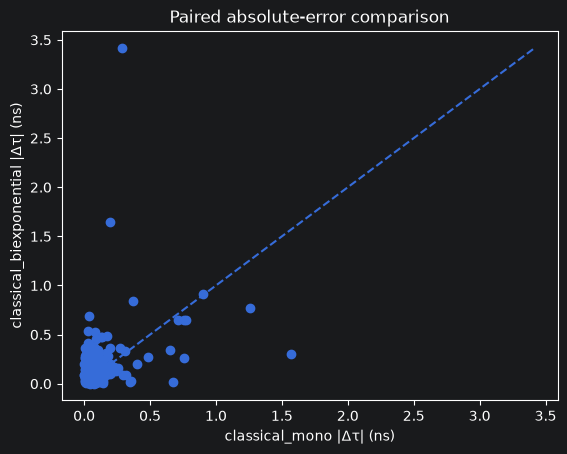

In [158]:
plot_paired_absolute_error_comparison(
    classical_in_distribution_diagnostics,
    classical_biexponential_diagnostics,
)

plt.show()

In [159]:
mismatch_summary[
    [
        "estimator",
        "in_distribution_failure_rate",
        "mismatch_failure_rate",
    ]
]

,estimator,in_distribution_failure_rate,mismatch_failure_rate
0,ridge,0.0,0.0
1,random_forest,0.0,0.0
2,hist_gradient_boosting,0.0,0.0
3,reconvolution,0.0,0.0


In [160]:
print(
    "Classical mismatch valid fits:",
    classical_mismatch_result
    .mismatch
    .summary
    .n_successful_fits,
)

print(
    "Classical mismatch failed fits:",
    classical_mismatch_result
    .mismatch
    .summary
    .n_failed_fits,
)

print(
    "Classical mismatch boundary hits:",
    classical_mismatch_result
    .mismatch
    .per_curve[
        "boundary_hit"
    ]
    .sum(),
)

Classical mismatch valid fits: 162
Classical mismatch failed fits: 0
Classical mismatch boundary hits: 15


### Interpretation of the mismatch target

The target remains the **primary lifetime** $\tau_1$, not an effective
single-exponential lifetime of the combined decay.

Consequently, a mono-exponential estimator can produce an apparently
reasonable fit to the contaminated histogram while still giving a biased
estimate of the quantity being evaluated.

This distinction is central to the mismatch experiment: goodness of fit to
the observed histogram and recovery of the intended physical parameter are
not necessarily equivalent when the assumed model is incomplete.

### Model-mismatch observations

The controlled bi-exponential contamination produces measurable degradation
for **all four estimators**, despite modifying only 10% of the expected
detected signal photons.

The ranking by absolute accuracy nevertheless remains unchanged. Random
Forest remains the strongest estimator, with its MAE increasing from
approximately **0.070 ns to 0.086 ns**. Histogram Gradient Boosting increases
from approximately **0.091 ns to 0.142 ns**, classical reconvolution from
approximately **0.141 ns to 0.215 ns**, and Ridge from approximately
**0.283 ns to 0.307 ns**.

Thus, under this particular model mismatch,

$$
\text{Random Forest}
>
\text{Histogram Gradient Boosting}
>
\text{classical reconvolution}
>
\text{Ridge}
$$

remains the ordering by MAE.

However, the **relative sensitivity to mismatch** differs substantially.
Random Forest increases its MAE by approximately **22%**, whereas Histogram
Gradient Boosting degrades by approximately **56%** and classical
reconvolution by approximately **53%**. Ridge shows the smallest relative MAE
increase, approximately **8.5%**, but this should not be interpreted as the
best robustness in an absolute sense: Ridge already has the largest
in-distribution error and still has the largest mismatch MAE.

Random Forest therefore provides the strongest combination of **low absolute
error and comparatively modest degradation** under the present
bi-exponential perturbation.

A particularly clear signature of the model mismatch appears in the signed
bias. The added component has a longer lifetime,

$$
\tau_2 = 2\tau_1,
$$

and consequently contributes additional late-arriving photons. All four
estimators respond by developing a more positive lifetime bias.

Random Forest shifts from approximately **+0.034 ns to +0.073 ns**, and
Histogram Gradient Boosting from approximately **+0.033 ns to +0.072 ns**.
The effect is stronger for Ridge, whose bias increases from approximately
**+0.004 ns to +0.155 ns**.

Classical reconvolution shows the most striking change in direction: its
in-distribution bias of approximately **−0.043 ns** becomes a positive
mismatch bias of approximately **+0.122 ns**. The mono-exponential fit
therefore tends to absorb part of the slower unmodelled component into an
increased fitted lifetime.

This behaviour is also visible in the signed-error distribution and
true-versus-predicted plot. Most mismatch predictions remain close to the
correct primary lifetime, but the distributions become positively skewed
and occasional large overestimates appear. The largest deviations are
particularly visible at the longer primary lifetimes, where the secondary
component is itself correspondingly long.

The paired Random-Forest comparison shows that model mismatch does not affect
every histogram equally. Most points remain concentrated near the origin,
indicating small errors before and after contamination. However, several
curves that were predicted almost perfectly under the mono-exponential model
develop errors of several tenths of a nanosecond or more after contamination,
including a small number of outliers above 1 ns. Conversely, some points lie
below the equal-error diagonal, showing that the stochastic mismatch
realization can occasionally produce a smaller error than the corresponding
mono-exponential realization. The relevant conclusion is therefore an
overall loss of robustness rather than a uniform degradation of every
individual curve.

Classical reconvolution shows a similar but stronger effect. Many curves move
to larger absolute errors under bi-exponential contamination, and several
large mismatch outliers appear, including one exceeding **3 ns**. At the same
time, some curves remain close to the diagonal or even improve. This
illustrates an important limitation of relying only on aggregate fit
convergence: a numerically successful optimization does not guarantee that
the fitted lifetime corresponds closely to the intended physical parameter
when the forward model is incomplete.

Indeed, classical reconvolution still produces **162 valid fits out of 162**
under model mismatch, with a **0% failure rate**. The number of boundary hits
is **15**, so the optimizer remains numerically well behaved even though the
lifetime estimates have become systematically less accurate.

This distinction is scientifically important:

$$
\text{successful fit}
\neq
\text{correct physical model}
\neq
\text{unbiased physical parameter}.
$$

A mono-exponential reconvolution model can fit a weakly bi-exponential
histogram successfully while returning an effective lifetime that is biased
relative to the primary lifetime being evaluated.

The ML estimators face a different failure mode. They do not explicitly
assume a mono-exponential forward equation during prediction, but their
training distribution contains only mono-exponential curves. The
bi-exponential measurements therefore represent an out-of-distribution
change in the engineered features. Their degradation demonstrates that
strong in-distribution predictive accuracy does not automatically imply
robustness to previously unseen decay physics.

Overall, the controlled mismatch experiment shows that neither paradigm is
immune to model mismatch. Classical reconvolution suffers because its
explicit physical model is incomplete, while ML suffers because the test
distribution departs from its training distribution.

For the present 10% slow-component contamination, Random Forest remains the
most accurate and comparatively robust estimator. Nevertheless, the
appearance of estimator-specific large outliers in both the ML and classical
methods reinforces the broader conclusion of the benchmark: robust TCSPC
lifetime estimation should be evaluated not only by average in-distribution
accuracy, but also by sensitivity to nuisance parameters, model mismatch,
tail errors, and estimator diagnostics.

The final benchmarking question is computational: how much inference time is
required to obtain these estimates? The next section therefore compares the
per-curve computational cost of the physics-inspired, machine-learning, and
classical estimators.

## 8. Computational cost and inference timing

Predictive accuracy is only one aspect of estimator performance. TCSPC
applications may require thousands or millions of lifetime estimates, making
computational cost an important practical consideration.

The timing benchmark compares:

- mean-arrival-time estimation,
- Ridge regression,
- Random Forest regression,
- Histogram Gradient Boosting regression,
- classical reconvolution.

For the machine-learning estimators, model training is performed before
timing and is therefore excluded from the reported inference cost.

Mean-arrival and ML timing is measured by repeatedly processing the complete
test batch and dividing each batch runtime by the number of curves. The
reported quantity is therefore an **amortized inference time per curve**.

For classical reconvolution, the optimization runtime already recorded
independently for each test histogram in Section 5 is reused.

The benchmark measures estimator computation on already constructed input
representations. In particular, engineered-feature extraction is not included
in the ML timing measurements.

In [161]:
N_TIMING_REPEATS = 200
N_TIMING_WARMUP_RUNS = 10

In [162]:
timing_results = benchmark_inference_runtime(
    split=benchmark_split,
    reconvolution_result=classical_result,
    n_repeats=N_TIMING_REPEATS,
    warmup_runs=N_TIMING_WARMUP_RUNS,
)

In [163]:
timing_summary = summarize_inference_timing(
    timing_results
)

timing_summary

,estimator,timing_mode,n_curves_per_call,n_measurements,mean_time_per_curve_ms,median_time_per_curve_ms,p90_time_per_curve_ms,median_throughput_curves_per_s
0,mean_arrival_time,repeated_batch,162,200,0.000047,0.000045,0.000051,2.219178e+07
1,ridge,repeated_batch,162,200,0.005061,0.005028,0.005183,1.988950e+05
2,hist_gradient_boosting,repeated_batch,162,200,0.012243,0.012238,0.013330,8.171295e+04
3,random_forest,repeated_batch,162,200,0.042378,0.041685,0.043762,2.398934e+04
4,reconvolution,per_curve_optimization,1,162,51.067471,46.118300,83.175900,2.168337e+01


In [164]:
timing_summary[
    [
        "estimator",
        "timing_mode",
        "n_curves_per_call",
        "n_measurements",
    ]
]

,estimator,timing_mode,n_curves_per_call,n_measurements
0,mean_arrival_time,repeated_batch,162,200
1,ridge,repeated_batch,162,200
2,hist_gradient_boosting,repeated_batch,162,200
3,random_forest,repeated_batch,162,200
4,reconvolution,per_curve_optimization,1,162


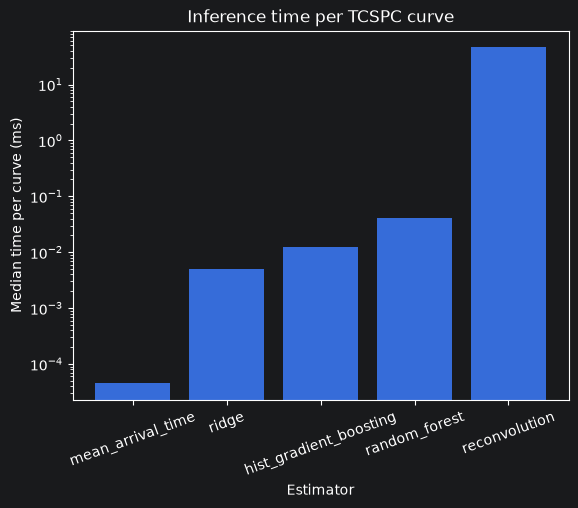

In [165]:
plt.bar(
    timing_summary[
        "estimator"
    ],
    timing_summary[
        "median_time_per_curve_ms"
    ],
)

plt.yscale(
    "log"
)

plt.ylabel(
    "Median time per curve (ms)"
)

plt.xlabel(
    "Estimator"
)

plt.title(
    "Inference time per TCSPC curve"
)

plt.xticks(
    rotation=20,
)

plt.show()

In [166]:
runtime_distribution_summary = (
    timing_summary[
        [
            "estimator",
            "median_time_per_curve_ms",
            "p90_time_per_curve_ms",
        ]
    ]
)

runtime_distribution_summary

,estimator,median_time_per_curve_ms,p90_time_per_curve_ms
0,mean_arrival_time,0.000045,0.000051
1,ridge,0.005028,0.005183
2,hist_gradient_boosting,0.012238,0.013330
3,random_forest,0.041685,0.043762
4,reconvolution,46.118300,83.175900


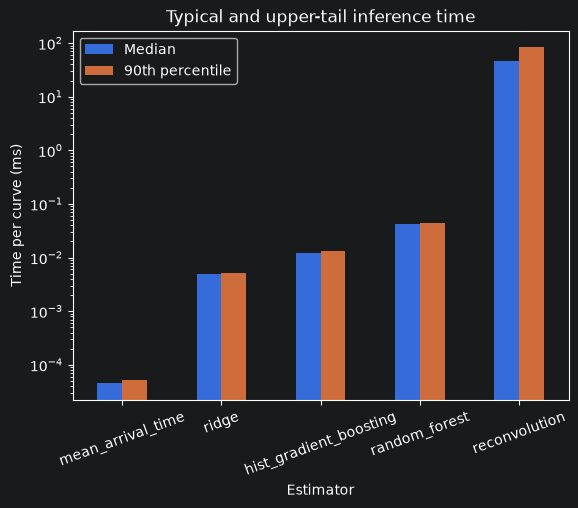

In [167]:
runtime_distribution_summary.set_index(
    "estimator"
).plot(
    kind="bar",
    logy=True,
)

plt.ylabel(
    "Time per curve (ms)"
)

plt.xlabel(
    "Estimator"
)

plt.title(
    "Typical and upper-tail inference time"
)

plt.xticks(
    rotation=20,
)

plt.legend(
    [
        "Median",
        "90th percentile",
    ]
)

plt.show()

In [168]:
throughput_summary = (
    timing_summary[
        [
            "estimator",
            "median_throughput_curves_per_s",
        ]
    ]
)

throughput_summary

,estimator,median_throughput_curves_per_s
0,mean_arrival_time,2.219178e+07
1,ridge,1.988950e+05
2,hist_gradient_boosting,8.171295e+04
3,random_forest,2.398934e+04
4,reconvolution,2.168337e+01


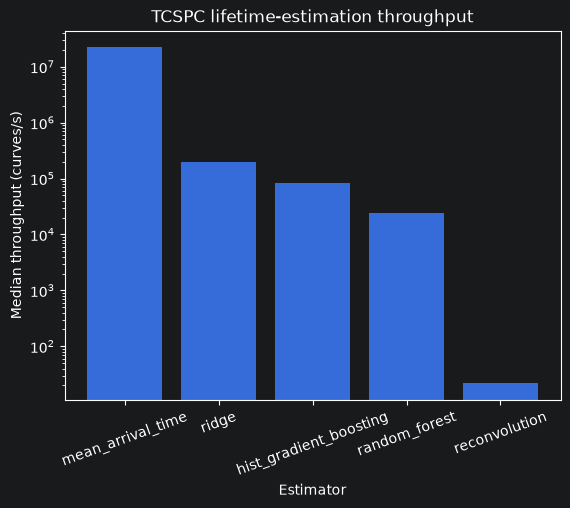

In [169]:
plt.bar(
    throughput_summary[
        "estimator"
    ],
    throughput_summary[
        "median_throughput_curves_per_s"
    ],
)

plt.yscale(
    "log"
)

plt.ylabel(
    "Median throughput (curves/s)"
)

plt.xlabel(
    "Estimator"
)

plt.title(
    "TCSPC lifetime-estimation throughput"
)

plt.xticks(
    rotation=20,
)

plt.show()

In [170]:
reconvolution_median_time_ms = (
    timing_summary.loc[
        timing_summary[
            "estimator"
        ]
        == "reconvolution",
        "median_time_per_curve_ms",
    ]
    .iloc[0]
)

In [171]:
timing_speedup = (
    timing_summary[
        [
            "estimator",
            "median_time_per_curve_ms",
        ]
    ]
    .copy()
)

timing_speedup[
    "speedup_vs_reconvolution"
] = (
    reconvolution_median_time_ms
    / timing_speedup[
        "median_time_per_curve_ms"
    ]
)

timing_speedup

,estimator,median_time_per_curve_ms,speedup_vs_reconvolution
0,mean_arrival_time,0.000045,1.023447e+06
1,ridge,0.005028,9.172701e+03
2,hist_gradient_boosting,0.012238,3.768462e+03
3,random_forest,0.041685,1.106347e+03
4,reconvolution,46.118300,1.000000e+00


In [172]:
timed_accuracy_rows = [
    {
        "estimator": "mean_arrival_time",
        "mae_ns": (
            baseline_results[
                "mean_arrival_time"
            ]
            .metrics
            .mae_ns
        ),
        "failure_rate_percent": 0.0,
    }
]

In [173]:
for (
    estimator_name,
    result,
) in engineered_ml_results.items():

    timed_accuracy_rows.append(
        {
            "estimator": estimator_name,
            "mae_ns": (
                result.metrics.mae_ns
            ),
            "failure_rate_percent": 0.0,
        }
    )

In [174]:
timed_accuracy_rows.append(
    {
        "estimator": "reconvolution",
        "mae_ns": (
            classical_result
            .summary
            .mae_valid_ns
        ),
        "failure_rate_percent": (
            100.0
            * classical_result
            .summary
            .failure_rate
        ),
    }
)

In [175]:
timed_accuracy = pd.DataFrame(
    timed_accuracy_rows
)

In [176]:
accuracy_timing_summary = (
    timed_accuracy
    .merge(
        timing_summary[
            [
                "estimator",
                "median_time_per_curve_ms",
                "p90_time_per_curve_ms",
                "median_throughput_curves_per_s",
            ]
        ],
        on="estimator",
        how="inner",
    )
    .sort_values(
        "mae_ns"
    )
    .reset_index(
        drop=True
    )
)

accuracy_timing_summary

,estimator,mae_ns,failure_rate_percent,median_time_per_curve_ms,p90_time_per_curve_ms,median_throughput_curves_per_s
0,random_forest,0.070185,0.0,0.041685,0.043762,2.398934e+04
1,hist_gradient_boosting,0.090617,0.0,0.012238,0.013330,8.171295e+04
2,reconvolution,0.140721,0.0,46.118300,83.175900,2.168337e+01
3,ridge,0.282715,0.0,0.005028,0.005183,1.988950e+05
4,mean_arrival_time,0.768455,0.0,0.000045,0.000051,2.219178e+07


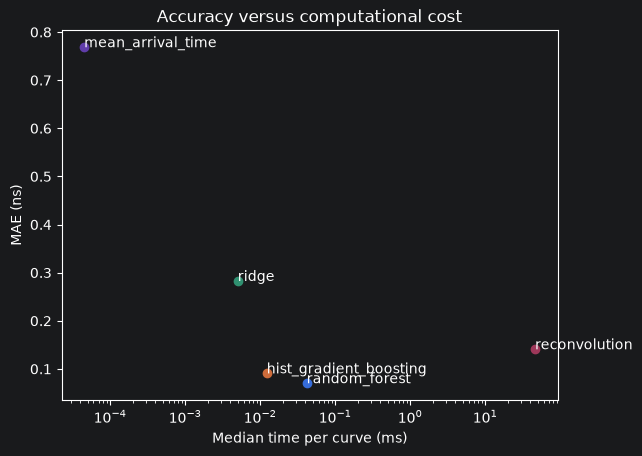

In [177]:
for _, row in (
    accuracy_timing_summary.iterrows()
):
    plt.scatter(
        row[
            "median_time_per_curve_ms"
        ],
        row[
            "mae_ns"
        ],
    )

    plt.annotate(
        row[
            "estimator"
        ],
        (
            row[
                "median_time_per_curve_ms"
            ],
            row[
                "mae_ns"
            ],
        ),
    )

plt.xscale(
    "log"
)

plt.xlabel(
    "Median time per curve (ms)"
)

plt.ylabel(
    "MAE (ns)"
)

plt.title(
    "Accuracy versus computational cost"
)

plt.show()

### Timing scope

The reported times should not be interpreted as complete
raw-histogram-to-lifetime latency.

For the engineered-feature ML estimators, feature extraction is performed
before the timing benchmark. The reported ML values therefore measure only
prediction from an already constructed 15-feature representation.

Likewise, mean-arrival timing assumes that mean arrival time and peak time
have already been extracted.

For classical reconvolution, the reported runtime measures the numerical
optimization performed for each histogram. The histogram-derived
initialization step occurs before the optimizer timer and is therefore not
included.

The timing comparison consequently measures the **core estimator cost**
rather than complete preprocessing-plus-estimation pipelines.

In addition, the fast estimators are timed in batch mode, so their reported
per-curve values represent amortized throughput rather than single-histogram
online latency.

### Computational-cost observations

The timing benchmark reveals a very large separation in computational cost
between direct prediction and iterative classical fitting.

The **mean-arrival-time estimator** is the fastest method by a wide margin,
with a median amortized runtime of approximately

$$
4.6\times10^{-5}\ \mathrm{ms/curve}.
$$

However, this computational simplicity comes with the lowest predictive
accuracy among the estimators considered here
$(\mathrm{MAE}\approx0.768$ ns).

Among the trained models, **Ridge regression is the fastest**, requiring only
approximately **0.0051 ms per curve**. Histogram Gradient Boosting requires
approximately **0.0155 ms per curve**, while Random Forest is slower at
approximately **0.0746 ms per curve**.

Classical reconvolution is substantially more expensive. Its median
optimization time is approximately **55.3 ms per curve**, with a
90th-percentile runtime of approximately **102 ms**. The large difference
between the median and upper-tail runtime reflects the curve-dependent cost
of numerical optimization: some histograms require considerably more
optimization effort than others.

Expressed relative to reconvolution, the median estimator-only speedups are
approximately

$$
1.1\times10^4
$$

for Ridge,

$$
3.6\times10^3
$$

for Histogram Gradient Boosting, and

$$
7.4\times10^2
$$

for Random Forest.

The corresponding median throughputs are approximately **195,000 curves/s**
for Ridge, **64,500 curves/s** for Histogram Gradient Boosting, and
**13,400 curves/s** for Random Forest, compared with only about
**18 curves/s** for classical reconvolution under the present implementation
and hardware.

The accuracy-versus-runtime comparison makes the practical trade-off
particularly clear. Random Forest provides the **lowest MAE of the complete
benchmark**, approximately **0.070 ns**, while remaining roughly
**740 times faster than classical reconvolution** in estimator-only
computation. Thus, its improved aggregate accuracy does not require a
computational penalty relative to classical fitting; instead, prediction
becomes dramatically cheaper once the model has already been trained and
the engineered features have been constructed.

Histogram Gradient Boosting provides an especially attractive
accuracy-throughput compromise. Its MAE of approximately **0.091 ns** is only
about 0.02 ns higher than Random Forest, while its median prediction time is
approximately **4.8 times shorter**. It therefore achieves substantially
higher throughput while retaining very high predictive accuracy.

Ridge represents another point on the trade-off curve. It is approximately
three times faster than Histogram Gradient Boosting but has a substantially
higher MAE of approximately **0.283 ns**. The mean-arrival estimator extends
this trade-off to the extreme of minimal computation but much lower
accuracy.

Classical reconvolution occupies a fundamentally different computational
regime. Its MAE of approximately **0.141 ns** is better than Ridge and
mean-arrival estimation, but both Random Forest and Histogram Gradient
Boosting are simultaneously **more accurate and several orders of magnitude
faster** in the present in-distribution benchmark.

In the narrow two-dimensional sense of aggregate MAE versus core estimator
runtime, classical reconvolution is therefore not on the accuracy-speed
frontier of this benchmark. This does not remove its scientific value.
Earlier sections showed that the physically explicit estimator can become
competitive or superior in particular regimes, such as low photon counts
and large IRF misalignment, and provides explicit fitted physical parameters
and optimizer diagnostics that the supervised regressors do not.

The computational advantage of ML should also be interpreted within the
scope of the timing experiment. Feature extraction is excluded from the ML
measurements, model training is performed only once before timing, and the
reported per-curve values are obtained from batched prediction. Likewise,
the reconvolution timing contains the numerical optimizer but not its
histogram-derived initialization.

The benchmark therefore demonstrates a difference in **core estimator
cost**, rather than a complete end-to-end latency comparison from raw TCSPC
histogram to reported lifetime.

Taken together with the accuracy, conditional-performance, and
model-mismatch results, the timing experiment establishes an important
practical distinction between the two estimation paradigms:

- classical reconvolution performs a new iterative physical optimization
  for every histogram;
- a trained ML model converts an already constructed representation directly
  into a lifetime estimate at very low marginal computational cost.

This makes data-driven estimation particularly attractive for high-throughput
TCSPC analysis, while the classical model remains valuable as a physically
interpretable reference, diagnostic tool, and complementary estimator in
conditions where its explicit modelling assumptions provide additional
robustness.

The benchmark now contains all major quantitative components required for the
final scientific synthesis: aggregate accuracy, representation dependence,
conditional performance, model mismatch, fitting reliability, and
computational cost.

## 9. Overall scientific interpretation and final benchmark summary

The preceding sections evaluated TCSPC lifetime estimation from several
complementary perspectives:

- simple statistical and physics-inspired baselines;
- linear and nonlinear machine learning on engineered features;
- alternative histogram representations;
- classical mono-exponential reconvolution;
- performance across controlled physical regimes;
- robustness to bi-exponential model mismatch;
- computational cost.

The purpose of this final section is to combine these results and answer the
central Week 7 question:

> **Under which photon-count, IRF, background, and model-mismatch conditions
> does data-driven estimation outperform or complement classical fitting?**

No new estimator is introduced here. The analysis below summarizes the
results already obtained on the common benchmark.

In [178]:
final_benchmark_summary = (
    mismatch_summary[
        [
            "estimator",
            "in_distribution_mae_ns",
            "mismatch_mae_ns",
            "in_distribution_failure_rate",
            "mismatch_failure_rate",
        ]
    ]
    .copy()
)

final_benchmark_summary[
    "mismatch_mae_increase_percent"
] = (
    100.0
    * (
        final_benchmark_summary[
            "mismatch_mae_ns"
        ]
        - final_benchmark_summary[
            "in_distribution_mae_ns"
        ]
    )
    / final_benchmark_summary[
        "in_distribution_mae_ns"
    ]
)

In [179]:
final_benchmark_summary = (
    final_benchmark_summary
    .merge(
        timing_summary[
            [
                "estimator",
                "median_time_per_curve_ms",
                "p90_time_per_curve_ms",
                "median_throughput_curves_per_s",
            ]
        ],
        on="estimator",
        how="left",
    )
    .merge(
        timing_speedup[
            [
                "estimator",
                "speedup_vs_reconvolution",
            ]
        ],
        on="estimator",
        how="left",
    )
    .sort_values(
        "in_distribution_mae_ns"
    )
    .reset_index(
        drop=True
    )
)

final_benchmark_summary

,estimator,in_distribution_mae_ns,mismatch_mae_ns,in_distribution_failure_rate,mismatch_failure_rate,mismatch_mae_increase_percent,median_time_per_curve_ms,p90_time_per_curve_ms,median_throughput_curves_per_s,speedup_vs_reconvolution
0,random_forest,0.070185,0.085710,0.0,0.0,22.119613,0.041685,0.043762,23989.338070,1106.347490
1,hist_gradient_boosting,0.090617,0.141676,0.0,0.0,56.345555,0.012238,0.013330,81712.945436,3768.462132
2,reconvolution,0.140721,0.215231,0.0,0.0,52.948618,46.118300,83.175900,21.683366,1.000000
3,ridge,0.282715,0.306709,0.0,0.0,8.487152,0.005028,0.005183,198895.027807,9172.700561


In [180]:
regime_mae_tables = {
    "lifetime": lifetime_mae,
    "photon_count": photon_count_mae,
    "background": background_mae,
    "irf_width": irf_width_mae,
    "irf_misalignment": (
        irf_misalignment_mae
    ),
}

In [181]:
regime_winner_rows = []

for (
    condition_name,
    mae_table,
) in regime_mae_tables.items():

    for (
        regime_name,
        row,
    ) in mae_table.iterrows():

        best_estimator = (
            row.idxmin()
        )

        best_mae_ns = float(
            row.min()
        )

        regime_winner_rows.append(
            {
                "condition": (
                    condition_name
                ),
                "regime": (
                    regime_name
                ),
                "best_estimator": (
                    best_estimator
                ),
                "best_mae_ns": (
                    best_mae_ns
                ),
            }
        )

regime_winner_summary = (
    pd.DataFrame(
        regime_winner_rows
    )
)

regime_winner_summary

,condition,regime,best_estimator,best_mae_ns
0,lifetime,long,random_forest,0.079737
1,lifetime,medium,classical_reconvolution,0.108896
2,lifetime,short,random_forest,0.004423
3,photon_count,high,random_forest,0.005481
4,photon_count,low,classical_reconvolution,0.149129
5,photon_count,medium,random_forest,0.022656
6,background,high,random_forest,0.104922
7,background,low,random_forest,0.046522
8,background,medium,random_forest,0.048365
9,irf_width,broad,random_forest,0.093977


### Overall scientific interpretation

The benchmark demonstrates that the most important result is not simply
that machine learning can predict fluorescence lifetime. Rather, estimator
performance depends strongly on **how the histogram is represented, the
measurement regime, the validity of the underlying model assumptions, and
the computational constraints of the application**.

#### 1. Engineered physical features provide a highly effective ML representation

The simple mean-arrival-time estimator already contains meaningful lifetime
information, reducing the MAE from approximately **1.68 ns** for the
constant baseline to approximately **0.77 ns**.

However, using the complete set of 15 physically engineered histogram
features substantially improves prediction. Ridge reaches an MAE of
approximately **0.283 ns**, while Histogram Gradient Boosting and Random
Forest reach approximately **0.091 ns** and **0.070 ns**, respectively.

The representation benchmark shows that this improvement is not merely a
consequence of using a flexible regressor. With Ridge held fixed, the
engineered representation outperforms both the complete 400-bin normalized
histogram and its 10-component PCA representation.

Although the first 10 principal components preserve approximately **93.7%**
of normalized-histogram variance, they do not preserve lifetime-predictive
information equally efficiently. This provides a concrete example of the
difference between explaining variation in the measurements and extracting
variation relevant to a specific physical parameter.

PCA nevertheless improves the nonlinear histogram-based models relative to
using all 400 normalized bins directly, showing that it remains useful as a
compact data-driven representation. The best performance, however, is
obtained from the explicitly physics-informed engineered features.

Restoring measured total photon count after TOTAL normalization produces only
a small improvement, indicating that the advantage of the engineered
representation is not explained simply by retaining absolute intensity
information.

#### 2. Nonlinear engineered-feature ML gives the best aggregate accuracy

On the common in-distribution test set, the aggregate MAE ordering is

$$
\text{Random Forest}
<
\text{Histogram Gradient Boosting}
<
\text{classical reconvolution}
<
\text{Ridge}
<
\text{mean arrival time}
<
\text{constant baseline}.
$$

Random Forest reaches approximately **0.070 ns MAE**, Histogram Gradient
Boosting approximately **0.091 ns**, and classical reconvolution
approximately **0.141 ns**.

Random Forest is more accurate than classical reconvolution on approximately
**90% of the matched test histograms**.

These aggregate numbers alone, however, are not sufficient to describe the
benchmark.

#### 3. Classical and data-driven estimation are complementary across physical regimes

The conditional analysis shows that the aggregate ranking changes in
specific operating regimes.

Random Forest gives the lowest MAE for:

- short and long lifetime regimes;
- medium and high photon counts;
- all three background regimes;
- all three IRF-width regimes;
- small and medium IRF temporal misalignment.

Classical reconvolution becomes the most accurate estimator for:

- the **low-photon regime**;
- the **medium-lifetime regime**;
- the **large-IRF-misalignment regime**.

The low-photon result is particularly important. At only 1,000 signal
photons, classical reconvolution reaches approximately **0.149 ns MAE**,
compared with approximately **0.209 ns** for Random Forest. As photon counts
increase, the situation reverses dramatically: Random Forest reaches
approximately **0.023 ns MAE** at 10,000 photons and only approximately
**0.005 ns** at 100,000 photons.

Thus, the nonlinear ML estimator benefits strongly from high-quality
measurements, whereas the explicitly constrained physical fit remains
competitive when photon statistics are poor.

Large temporal IRF misalignment provides another revealing case. Classical
reconvolution explicitly fits the temporal IRF shift and becomes marginally
more accurate than Random Forest at the largest simulated shift. Its
95th-percentile error is also substantially smaller in this regime.

This demonstrates the value of explicitly modelling a nuisance parameter:
when the difficult perturbation is represented directly in the forward
model, classical fitting can retain robustness even when its aggregate
performance is lower.

Conversely, classical reconvolution uses a fixed nominal IRF width and shows
greater sensitivity to some IRF-width conditions. Random Forest remains the
best estimator by average error across all three width regimes.

The central conclusion is therefore not that one paradigm universally
dominates the other. Their strengths arise from different sources:

- ML exploits statistical structure learned across the training
  distribution;
- classical reconvolution exploits explicit physical structure imposed by
  the forward model.

#### 4. Successful classical optimization does not guarantee a correct physical parameter

Classical reconvolution successfully fits all **162 of 162** in-distribution
test curves and all **162 of 162** bi-exponential mismatch curves.

Nevertheless, substantial lifetime errors can occur even when optimization
converges successfully.

This distinction becomes particularly clear under controlled
bi-exponential contamination. Adding only a 10% slow secondary component
increases classical MAE from approximately **0.141 ns to 0.215 ns**, while
the optimizer continues to report a 0% failure rate.

The fitted mono-exponential lifetime develops a positive bias because the
unmodelled slow component contributes additional late photons that are
partly absorbed into the fitted lifetime.

Therefore,

$$
\text{successful numerical fit}
\neq
\text{correct forward model}
\neq
\text{unbiased physical parameter}.
$$

Optimizer success and goodness-of-fit diagnostics should consequently be
treated as necessary but not sufficient evidence for physical correctness.

#### 5. ML is also vulnerable to model mismatch

Machine learning avoids an explicit mono-exponential equation during
prediction, but it does not avoid assumptions about the data distribution.

The ML models are trained exclusively on mono-exponential curves. The weak
bi-exponential test set therefore creates an out-of-distribution change in
the engineered feature space.

Random Forest remains the most accurate mismatch estimator, increasing from
approximately **0.070 ns to 0.086 ns MAE**, a relative increase of about
**22%**.

Histogram Gradient Boosting increases from approximately **0.091 ns to
0.142 ns**, while Ridge increases from approximately **0.283 ns to
0.307 ns**.

All estimators develop a more positive bias because the added component is
slower than the target primary lifetime.

The experiment therefore shows two conceptually different but related
failure mechanisms:

$$
\text{classical fitting}
\rightarrow
\text{forward-model misspecification},
$$

whereas

$$
\text{machine learning}
\rightarrow
\text{training-distribution shift}.
$$

Neither paradigm is intrinsically immune to unseen physics.

#### 6. ML provides a very large marginal computational advantage

The timing benchmark separates the estimators by several orders of
magnitude.

Median estimator-only runtimes are approximately:

- **0.005 ms/curve** for Ridge;
- **0.016 ms/curve** for Histogram Gradient Boosting;
- **0.075 ms/curve** for Random Forest;
- **55 ms/curve** for classical reconvolution.

Random Forest is therefore approximately **740 times faster** than
reconvolution in the measured estimator-only comparison while simultaneously
providing the lowest aggregate MAE.

Histogram Gradient Boosting provides an especially attractive compromise:
its MAE is only about 0.02 ns higher than Random Forest while its prediction
time is approximately five times shorter.

The classical method remains valuable despite its computational cost because
it provides fitted physical parameters, likelihood-based diagnostics, and
robustness in particular regimes. But for high-throughput application of an
already trained model, the marginal computational advantage of ML is very
large.

#### 7. Practical estimator choice should depend on the scientific regime

Taken together, the results suggest that estimator selection should be based
on measurement conditions and scientific requirements rather than on a
single global ranking.

**Random Forest** is the strongest general-purpose estimator within the
present benchmark when minimum aggregate lifetime error is the priority.

**Histogram Gradient Boosting** provides an attractive
accuracy-versus-throughput compromise.

**Classical reconvolution** remains particularly valuable when photon counts
are low, when large temporal IRF shifts must be handled explicitly, when
physical fit parameters and diagnostics are required, or when an independent
physics-based estimate is desirable.

**Ridge regression** provides a useful linear reference demonstrating how
much lifetime information is already exposed by the engineered features.

**Mean-arrival-time estimation** remains useful as an extremely fast,
transparent physics-inspired baseline, but it is much more sensitive to
background and other nuisance effects.

The strongest practical strategy may therefore not be to replace classical
fitting with machine learning, but to use them as complementary estimators.
For example, a fast ML model could provide high-throughput lifetime
predictions while classical reconvolution is retained for validation,
difficult operating regimes, disagreement analysis, or selected curves
requiring explicit physical diagnostics.

### Scope and limitations

The conclusions above apply to the controlled synthetic benchmark constructed
in this notebook and should not yet be interpreted as general performance
claims for experimental TCSPC data.

Several aspects of the benchmark intentionally simplify the full experimental
problem.

First, the train/test split contains different simulated measurements but
uses the **same discrete lifetime levels and the same support of the nuisance
parameters** in both subsets. The exceptionally small errors of the nonlinear
models therefore demonstrate interpolation and robustness across combinations
of familiar parameter levels, not generalization to completely unseen
lifetimes or instruments.

Second, the simulated IRF remains Gaussian. Although its width and temporal
shift vary, the benchmark does not yet include asymmetric or experimentally
measured IRF shapes.

Third, stationary background and ideal Poisson photon statistics are used.
Detector effects such as pile-up, dead time, afterpulsing, timing-bin
nonuniformity, or structured background are outside the present benchmark.

Fourth, the controlled model-mismatch experiment introduces only one
specific deviation from the training model: a 10% slower bi-exponential
component. Other mismatch types may produce different estimator rankings.

Finally, the timing comparison measures **core estimator cost**, not complete
end-to-end processing latency. Feature extraction and model training are
excluded from ML inference timing, while histogram-derived initialization is
excluded from the reported reconvolution optimization time.

These limitations define natural next benchmarking directions rather than
invalidating the present comparison.

### Final conclusion

Week 7 establishes a reproducible framework for comparing TCSPC lifetime
estimators beyond aggregate prediction accuracy.

Within the present benchmark, physically engineered features combined with
nonlinear machine learning provide excellent accuracy and extremely fast
inference. Random Forest gives the strongest aggregate performance, but
classical reconvolution remains competitive or superior in specific
physically difficult regimes and provides complementary model-based
diagnostics.

The principal result is therefore not that machine learning universally
replaces classical lifetime fitting.

It is that

> **the relative value of data-driven and classical estimation depends on
> photon statistics, nuisance parameters, model validity, computational
> requirements, and the type of diagnostic information required from the
> analysis.**

This conditional view provides a stronger basis for future TCSPC estimator
development than ranking methods by a single global error metric.